<h1> <b>Predicting smartphone value : analyzing price, ratings and performance through ML </b><h1>

Name : Jean-Jacques Gougassian

Professor : Dr. Mirco Ravanelli

Tutorial Assistant : Gianfranco Dumoulin

<h2><b>Abstract</b> </h2>

The goal of this project is to predict smartphone prices and additional key attributes, such as resale prices and battery performance scores, using machine learning models. The dataset is sourced from Kaggle (https://www.kaggle.com/code/abhijitdahatonde/analysis-on-smartphones?select=smartphones.csv) and contains various smartphone specifications like processor type, RAM, battery capacity, and camera quality. To improve accuracy and expand prediction capabilities beyond price estimation, I will enhance the dataset by adding unique features obtained from external sources.
This project will implement a mix of conventional and unconventional models, including XGBoost, Bayesian Ridge Regression, and Multilayer Perceptron, alongside classic baselines like Random Forest. These models will be evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared (R²) to determine their predictive power.
Some of the main challenges include data inconsistencies, feature selection, handling categorical variables, potential biases and ensuring that additional features enhance predictions rather than introduce noise. This project explores different machine learning techniques to create a smarter way to evaluate smartphone prices, helping both consumers and manufacturers make better, data-backed decisions.

<h2><b>Introduction</b> </h2>

Smartphone pricing plays a central role in the mobile device ecosystem, especially when it comes to second-hand markets. With new phone models being released on a near-annual basis, resale value becomes a key consideration for users looking to upgrade. Unfortunately, predicting how much a used phone is worth is far from straightforward. Not only do prices fluctuate over time, but a smartphone’s resale value depends on numerous factors: its brand, specifications, condition, and even seemingly minor features like camera resolution or battery capacity. As such, there's a growing need for reliable, data-driven methods that estimate the resale value of smartphones based on technical specifications alone.

The purpose of this project is to predict smartphone resale prices and explore which machine learning techniques are most effective for this task. I use a combination of scraped and external datasets that include features like internal memory, RAM, camera resolution, battery capacity, and price. While some platforms offer resale estimates, they often rely on proprietary algorithms, making open, data-driven approaches like this especially valuable.

One of the main challenges with this task is the inconsistency in data formats and naming conventions. Smartphones with nearly identical specifications may be named slightly differently across datasets, or have variants with minor differences in storage or connectivity. For example, a phone model with 128GB storage may appear multiple times with variations in 5G support or front camera resolution. Matching these entries becomes a delicate task that requires a combination of preprocessing, fuzzy matching, and conditional logic to avoid false positives and missed merges.

Another difficulty is the absence of direct resale price data for many devices. While the dataset may include the original retail price of a phone, the used price is often missing or needs to be estimated from a similar model. To address this, a multi-step strategy was developed to merge external resale price data based on relaxed attribute matching, such as allowing small differences in battery or memory specs. If a match is found, a normalized price ratio (resale price divided by retail price) can be calculated and used to estimate the missing resale price for similar devices.

Finally, the project tackles the broader challenge of generalizing price predictions in the face of real-world market variability. Even among phones with identical specifications, resale prices may differ due to brand perception, release year, or other hidden factors. As a result, building a robust model that can interpolate missing values without overfitting to noise is a key part of the pipeline. While perfect accuracy is not the goal, providing a reasonable, data-driven estimate of a phone’s second-hand value can be extremely valuable for price comparison platforms, recommender systems, or users making resale decisions.

This project highlights the intersection of data cleaning, feature engineering, and applied machine learning, and lays the groundwork for more advanced predictive pricing systems that incorporate time-based depreciation trends and user sentiment in the future.

<h2><b>Originality & Approach</b> </h2>

While previous studies have typically focused on predicting either smartphone price, resale value, or battery life in isolation using basic models and some features, this project will bring all three prediction tasks together in a single, unified pipeline. I’ll start by collecting and cleaning smartphone specs, then manually enrich the dataset by scraping real-world battery benchmarks from GSMArena and estimating resale prices through smart matching with an external used-device dataset. Instead of relying on pre-structured datasets, I’ll focus on feature engineering, data augmentation, and interpretability to build a more customized solution. I’ll also explore models like Bayesian regression and integrate embeddings and neural networks (MLP) to better capture the structure of categorical data. The entire pipeline will be built from scratch to ensure originality and will reflect my own learning goals in applying machine learning to real-world problems.

<h2><b>Download Dataset</b> </h2>

The dataset used in this project is a smartphone specifications dataset originally compiled from Kaggle. It contains 980 entries, each corresponding to a smartphone model or variant, along with columns like model name, brand, release year, chipset, RAM, storage, battery capacity, and price.

To make the dataset accessible and easy to use, it has been uploaded to Google Drive and can be downloaded using the code below.

Additionally, I enriched the main dataset with extra target columns such as battery endurance by scraping data from GSMArena, and these values are included in the same file. Later in the project, I will incorporate a second dataset from Kaggle (https://www.kaggle.com/code/sasakitetsuya/used-mobile-phone-price-prediction-by-6-models), used_device_data, which provides smartphone resale prices. This dataset will be merged with the main one to improve the accuracy of resale value prediction.


In [ ]:
# Install gdown to download the file directly from Google Drive
!pip install -q gdown

# Download the dataset using its public Google Drive file ID
!gdown --id 1YMBb8Y3T6DgYxh37XkP9JC9UNiuO5Stc -O smartphones.csv
!gdown --id 19p0W8NcONQxBz1hDRrYSV1vVSh0OToBs -O used_device_data.csv

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1YMBb8Y3T6DgYxh37XkP9JC9UNiuO5Stc
To: /content/smartphones.csv
100% 104k/104k [00:00<00:00, 65.0MB/s]
/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=19p0W8NcONQxBz1hDRrYSV1vVSh0OToBs
To: /content/used_device_data.csv
100% 278k/278k [00:00<00:00, 31.3MB/s]


Import all the important dependencies that will be used in this project

In [143]:
import pandas as pd
import numpy as np
import requests
from bs4 import BeautifulSoup
import re
!pip install rapidfuzz
from rapidfuzz import process, fuzz
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import torch
from torch import nn
import random
import xgboost

<h2><b>Preprocessing</b> </h2>

First look at the dataset

In [210]:
smartphone_df = pd.read_csv('smartphones.csv')
smartphone_df.head()

,brand_name,model,price,avg_rating,5G_or_not,processor_brand,num_cores,processor_speed,battery_capacity,fast_charging_available,...,internal_memory,screen_size,refresh_rate,num_rear_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,resolution_height,resolution_width
0,apple,Apple iPhone 11,38999,7.3,0,bionic,6.0,2.65,3110.0,0,...,64,6.1,60,2,ios,12.0,12.0,0,1792,828
1,apple,Apple iPhone 11 (128GB),46999,7.5,0,bionic,6.0,2.65,3110.0,0,...,128,6.1,60,2,ios,12.0,12.0,0,1792,828
2,apple,Apple iPhone 11 Pro Max,109900,7.7,0,bionic,6.0,2.65,3500.0,1,...,64,6.5,60,3,ios,12.0,12.0,0,2688,1242
3,apple,Apple iPhone 12,51999,7.4,1,bionic,6.0,3.10,NaN,0,...,64,6.1,60,2,ios,12.0,12.0,0,2532,1170
4,apple,Apple iPhone 12 (128GB),55999,7.5,1,bionic,6.0,3.10,NaN,0,...,128,6.1,60,2,ios,12.0,12.0,0,2532,1170


<h3>Detecting outliers using Interquartile Range (IQR) method :<h3>

Lower bound: -20739.75
Upper bound: 69230.25


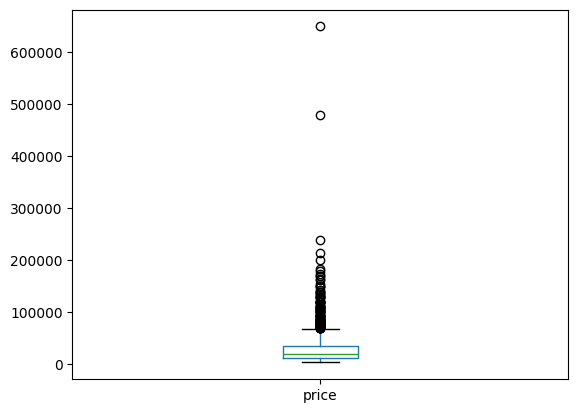

In [213]:
def detect_price_outliers(smartphone_df):
    """
    Detects outliers in the 'price' column of a smartphone dataset using the IQR method.
    Returns a sorted DataFrame of detected outliers and displays a boxplot of the price distribution.

    Parameters:
    -----------
    smartphone_df : pd.DataFrame
        A pandas DataFrame containing at least the columns 'model' and 'price'.

    Returns:
    --------
    pd.DataFrame
        A DataFrame listing the models and prices identified as outliers,
        sorted in ascending order by price.

    Example:
    --------
    >>> outliers_df = detect_price_outliers(smartphone_df)
    >>> print(outliers_df.head())
    """
    # Extract model and price columns
    prices = smartphone_df[['model', 'price']].copy()

    # Ensure 'price' column is numeric
    prices['price'] = pd.to_numeric(prices['price'], errors='coerce')

    # Compute IQR bounds
    Q1 = prices['price'].quantile(0.25)
    Q3 = prices['price'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Print the IQR bounds
    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)

    # Detect outliers
    outliers_list = []
    for _, row in prices.iterrows():
        if row['price'] < lower_bound or row['price'] > upper_bound:
            outliers_list.append([row['model'], row['price']])

    # Create a DataFrame of outliers, sorted by price
    outliers_df = pd.DataFrame(outliers_list, columns=['model', 'price'])
    outliers_df = outliers_df.sort_values(by='price', ascending=True)

    # Show the boxplot of price distribution
    prices.boxplot(column=['price'], grid=False)

    return outliers_df

# Call the function and show the result
outliers_df = detect_price_outliers(smartphone_df)

In my dataset, I identified several outliers in the smartphone prices using the Interquartile Range (IQR) method. While these prices fall outside the typical range, I chose not to remove them. These values still represent real-world devices, such as high-end flagship models or extremely budget-friendly phones, and can provide valuable insights. Since they reflect actual market behavior, I believe they are important to keep for building a more realistic and robust model.










<h3>Handling null values <h3>

In [214]:
smartphone_df.isnull().sum()

,0
brand_name,0
model,0
price,0
avg_rating,101
5G_or_not,0
processor_brand,20
num_cores,6
processor_speed,42
battery_capacity,11
fast_charging_available,0


In the dataset, several columns contain missing values that need to be addressed before modeling. Notably, fast_charging has the highest number of nulls (211), followed by avg_rating, processor_speed, and processor_brand. Other columns like num_cores, primary_camera_front, os, and battery_capacity have fewer missing values, making them manageable. These missing entries span various categories such as technical specs, camera features, and charging capabilities — all of which are essential for accurate prediction and analysis.



In [215]:
def clean_missing_values(smartphone_df):
    """
    Cleans missing values in the smartphone dataset by applying a mix of forward fill,
    manual corrections, and grouped statistical imputations.

    Specifically:
    - Applies forward-fill on processor and OS-related columns.
    - Fills battery capacities for known iPhone models using trusted fixed values.
    - Imputes 'fast_charging' values based on brand-level averages and global mean.
    - Fills missing average ratings with the column mean.

    Parameters:
    -----------
    smartphone_df : pd.DataFrame
        A pandas DataFrame containing smartphone information, including columns like
        'model', 'processor_brand', 'battery_capacity', 'fast_charging', etc.

    Returns:
    --------
    pd.DataFrame
        A cleaned version of the input DataFrame with missing values handled.

    Example:
    --------
    >>> smartphone_df = clean_missing_values(smartphone_df)
    >>> smartphone_df.isnull().sum()
    """
    # Forward-fill columns where smartphones of the same type are grouped together
    smartphone_df[['processor_brand','num_cores', 'processor_speed', 'os', 'primary_camera_front']] = (
        smartphone_df[['processor_brand','num_cores', 'processor_speed', 'os', 'primary_camera_front']].ffill()
    )

    # Manually assign known battery capacities from trusted sources for specific iPhone models
    smartphone_df.loc[
        (smartphone_df['model'].str.contains('Apple iPhone 12', case=False, na=False)) &
        ~(smartphone_df['model'].str.contains('Mini', case=False, na=False)),
        'battery_capacity'
    ] = 2815

    smartphone_df.loc[
        smartphone_df['model'].str.contains('Apple iPhone 12 Mini', case=False, na=False),
        'battery_capacity'
    ] = 2227

    smartphone_df.loc[
        (smartphone_df['model'].str.contains('Apple iPhone 15 Pro', case=False, na=False)) &
        ~(smartphone_df['model'].str.contains('Max', case=False, na=False)),
        'battery_capacity'
    ] = 3274

    smartphone_df.loc[
        smartphone_df['model'].str.contains('Apple iPhone SE 2020', case=False, na=False),
        'battery_capacity'
    ] = 1821

    smartphone_df.loc[
        smartphone_df['model'].str.contains('Apple iPhone SE 3 2022', case=False, na=False),
        'battery_capacity'
    ] = 2018

    smartphone_df.loc[
        smartphone_df['model'].str.contains('Apple iPhone SE 4', case=False, na=False),
        'battery_capacity'
    ] = 3279

    # Nullify 'fast_charging' where fast charging is unavailable
    smartphone_df.loc[smartphone_df['fast_charging_available'] == 0, 'fast_charging'] = np.nan

    # Fill missing 'fast_charging' values using the mean value grouped by brand
    smartphone_df['fast_charging'] = smartphone_df.groupby('brand_name')['fast_charging'].transform(
        lambda x: x.fillna(x.mean())
    )

    # Fallback: fill any remaining nulls with the overall average fast charging value
    smartphone_df['fast_charging'] = smartphone_df['fast_charging'].fillna(smartphone_df['fast_charging'].mean())

    # Fill missing average ratings with the column mean
    smartphone_df['avg_rating'] = smartphone_df['avg_rating'].fillna(smartphone_df['avg_rating'].mean())

    return smartphone_df

# Call the function
smartphone_df = clean_missing_values(smartphone_df)

To handle these missing values, I used different strategies depending on the column. For processor_brand, num_cores, processor_speed, os, and primary_camera_front, I applied forward fill, since smartphones with similar specs are typically grouped together in the dataset, making this a reasonable choice. For battery_capacity, the number of missing entries was small, so I manually searched for the correct values on Google and entered them directly. This ensured high accuracy without requiring much time. For the avg_rating column, I decided to retain it as a potential feature since user satisfaction often correlates with pricing and perceived battery performance. I filled the missing values using the column's mean to maintain consistency.
Lastly, for fast_charging, I first set it to NaN for models where fast charging isn’t available, then filled in the remaining missing values using the average fast charging speed grouped by brand, based on the assumption that manufacturers tend to use similar charging specs across their devices.For any remaining null values (typically in cases where no other models from that brand had data), I used the overall average fast charging speed as a fallback. This ensures consistency while preserving as much useful information as possible.
Overall, this multi-step approach balances efficiency and data quality.

In [216]:
smartphone_df.isnull().sum()

,0
brand_name,0
model,0
price,0
avg_rating,0
5G_or_not,0
processor_brand,0
num_cores,0
processor_speed,0
battery_capacity,0
fast_charging_available,0


We now have no null values!

<h3>Merging battery performance to our dataset<h3>

To enrich my dataset with more detailed battery performance metrics, I decided to scrape information from GSMArena’s battery test page https://www.gsmarena.com/battery-test.php3?idPhone=11251#show. This site provides valuable benchmarks for various devices, and the data will be useful for training and evaluating our model. I used BeautifulSoup to parse the HTML content and extract the battery table structure as well as detailed per-device battery stats.

The battery-related columns I’m collecting are:

Endurance Rating: A composite score estimating overall battery life in hours.

Talk Time: Continuous 3G talk duration.

Web Browsing: Time a phone can browse the web continuously.

Video Playback: Time a phone can play videos before running out of charge.

These columns offer deeper insight into real-world battery performance and will serve as valuable targets or features in future modeling steps.

In [217]:
def extract_battery_specs(url):
    """
    Scrapes battery performance metrics for smartphones from a GSMArena battery test URL.

    Functionality:
    --------------
    - Sends an HTTP GET request to the provided GSMArena battery test page.
    - Extracts the table header to understand the structure of the data.
    - Parses each smartphone row to retrieve endurance rating, talk time,
      web browsing time, and video playback time.
    - Stores the scraped values in a dictionary keyed by smartphone name.

    Parameters:
    -----------
    url : str
        The URL of the GSMArena battery test page to scrape.

    Returns:
    --------
    dict
        A dictionary where keys are smartphone model names (str), and values
        are lists of battery performance specs (list of str), typically:
        [endurance rating, talk time, web browsing time, video playback time].

    Example:
    --------
    >>> url = 'https://www.gsmarena.com/battery-test.php3?idPhone=11251#show'
    >>> sp_dict = extract_battery_specs(url)
    >>> print(sp_dict['Samsung Galaxy S21'])
    ['91h', '25:00h', '12:20h', '15:45h']
    """
    response = requests.get(url)
    soup = BeautifulSoup(response.content, 'html.parser')

    # Locate the main battery test table
    table = soup.find('table', class_=['keywords', 'persist-area'])
    header_row = table.find('thead').find('tr')

    # Extract the column headers
    new_columns = [th.get_text(separator=' ', strip=True) for th in header_row.find_all('th')]
    print("Battery Table Columns:", new_columns)

    div = soup.find('div', class_= 'st-text')
    tds = div.find_all('td')
    sp_dict = {}
    i = 0
    k = 0
    while i < len(tds):
        if 'lalign' in tds[i].get('class', []):
            sp_name = tds[i].get_text(separator=' ', strip=True)
            specs = []

            for j in range (1,5):
                specs.append(tds[i+j].get_text(separator=' ', strip=True))
                k+=1
            sp_dict[sp_name] = specs
            i+=5
        else :
            i+=1

    #print(sp_dict)
    return sp_dict

url = 'https://www.gsmarena.com/battery-test.php3?idPhone=11251#show'
sp_dict = extract_battery_specs(url)

Battery Table Columns: ['Phone', 'Endurance rating', 'Talk time', 'Web browsing', 'Video playback', 'Custom rating']


To integrate the scraped battery performance data into my main dataset, I created a simple name cleaning function to standardize smartphone model names for better matching. The function removes any text inside parentheses, converts the string to lowercase, and replaces symbols like + with their word equivalents. This helps ensure consistent formatting between the scraped names and the names in the original dataset. Then, for each entry in the scraped dictionary, I find its corresponding row in the main DataFrame and populate five new battery-related columns: endurance_rating, talk_time, web_browsing, video_playback, and custom_rating. This step enriches the dataset with valuable real-world battery metrics that can improve model accuracy and deepen analysis.

In [219]:
def clean_name(name):
    """
    Cleans a smartphone model name string for standardization and fuzzy matching.

    Functionality:
    --------------
    - Converts the string to lowercase.
    - Removes any content enclosed in parentheses.
    - Replaces '+' symbols with the word 'plus'.
    - Removes extra whitespace.

    Parameters:
    -----------
    name : str
        The smartphone model name to clean.

    Returns:
    --------
    str
        A cleaned and standardized version of the input name.

    Example:
    --------
    >>> clean_name("Samsung Galaxy S21+ (2021)")
    'samsung galaxy s21 plus'
    """
    name = name.lower()
    name = re.sub(r'\(.*?\)', '', name)
    name = re.sub(r'\s+', ' ', name)
    name = re.sub(r'\+', ' plus', name)
    return name.strip()

# Function to iterate over the scraped battery specs dictionary
def find_corresponding_row(sp_dict):
  """
    Assigns battery performance specs from a scraped dictionary to the matching rows in the main DataFrame.

    Functionality:
    --------------
    - Iterates over the dictionary of smartphone battery specs.
    - Cleans both the scraped name and the model names in the DataFrame using `clean_name`.
    - If a match is found, updates the corresponding row in the DataFrame with:
      'endurance_rating', 'talk_time', 'web_browsing', and 'video_playback'.

    Parameters:
    -----------
    sp_dict : dict
        A dictionary where keys are raw smartphone names (str), and values are lists
        of battery specs (list of str), scraped from GSMArena.

    Returns:
    --------
    None
        Updates the `smartphone_df` DataFrame in place.

    Example:
    --------
    >>> find_corresponding_row(sp_dict)
    # Updates the 'smartphone_df' DataFrame based on matching cleaned names
    """
  for smartphone, specs in sp_dict.items():
      # Clean the name of the scraped smartphone model
      cleaned_name = clean_name(smartphone)

      # Apply the same cleaning to all model names in the dataframe and find a match
      matching_row = smartphone_df['model'].apply(clean_name) == cleaned_name

      # If a match is found, assign the scraped battery performance values to the corresponding columns
      smartphone_df.loc[matching_row, 'endurance_rating'] = specs[0]
      smartphone_df.loc[matching_row, 'talk_time'] = specs[1]
      smartphone_df.loc[matching_row, 'web_browsing'] = specs[2]
      smartphone_df.loc[matching_row, 'video_playback'] = specs[3]

find_corresponding_row(sp_dict)



A look at our new dataset :

In [220]:
smartphone_df.head()

,brand_name,model,price,avg_rating,5G_or_not,processor_brand,num_cores,processor_speed,battery_capacity,fast_charging_available,...,os,primary_camera_rear,primary_camera_front,extended_memory_available,resolution_height,resolution_width,endurance_rating,talk_time,web_browsing,video_playback
0,apple,Apple iPhone 11,38999,7.3,0,bionic,6.0,2.65,3110.0,0,...,ios,12.0,12.0,0,1792,828,94h,17:45h,15:29h,18:43h
1,apple,Apple iPhone 11 (128GB),46999,7.5,0,bionic,6.0,2.65,3110.0,0,...,ios,12.0,12.0,0,1792,828,94h,17:45h,15:29h,18:43h
2,apple,Apple iPhone 11 Pro Max,109900,7.7,0,bionic,6.0,2.65,3500.0,1,...,ios,12.0,12.0,0,2688,1242,102h,21:03h,15:05h,19:30h
3,apple,Apple iPhone 12,51999,7.4,1,bionic,6.0,3.10,2815.0,0,...,ios,12.0,12.0,0,2532,1170,84h,19:27h,12:48h,13:04h
4,apple,Apple iPhone 12 (128GB),55999,7.5,1,bionic,6.0,3.10,2815.0,0,...,ios,12.0,12.0,0,2532,1170,84h,19:27h,12:48h,13:04h


In [152]:
smartphone_df.isnull().sum()

,0
brand_name,0
model,0
price,0
avg_rating,0
5G_or_not,0
processor_brand,0
num_cores,0
processor_speed,0
battery_capacity,0
fast_charging_available,0


Despite our initial attempt to match and merge battery specs using cleaned names, a significant number (761) of rows still have null values in the endurance_rating, talk_time, web_browsing, video_playback, and custom_rating columns. This is likely due to small variations or inconsistencies in model naming between the scraped data and our main dataset. As a result, many scraped models couldn't be matched directly. To address this, we will need to explore more flexible merging techniques, such as fuzzy matching using libraries like RapidFuzz along with multiple fallbacks, to better align entries across datasets.

In [222]:
EDITIONS = ['Pro', 'Ultra', 'SE', 'Mini', 'Plus', 'Max']

# Extract the brand from the model name (e.g., 'Samsung Galaxy S21' → 'samsung')
def get_brand(model):
    return model.split()[0].lower()

# Check if the model is a standard version (no edition keywords)
def is_standard(model):
    return all(edition.lower() not in model.lower() for edition in EDITIONS)

# Identify the edition (e.g., 'Pro', 'Mini') if present in the model name
def get_edition(model):
    for edition in EDITIONS:
        if edition.lower() in model.lower():
            return edition.lower()
    return None

# Extract the series name from the model (e.g., 'Galaxy S21 Ultra' → 's21 ultra')
def get_series(model):
    tokens = model.lower().split()
    return " ".join(tokens[1:3]) if len(tokens) > 2 else " ".join(tokens[1:])

# Convert time string format (e.g., '4:30h') to total minutes
def convertToMinutes(string):
    string = string.split(':')
    hours = int(string[0])
    minutes_str = re.sub(r'h', '', string[1])
    minutes = int(minutes_str)
    total_minutes = minutes + hours*60
    return total_minutes

# Convert numeric hours to 'xh' format string
def convertEnduranceToString(num):
    return str(round(num)) + "h"

# Convert minutes to 'hh:mmh' format string
def convertToHours(total_minutes):
    hours = total_minutes // 60
    minutes = total_minutes % 60
    return str(int(hours)) + ':' + f'{int(minutes):02d}' + 'h'

# Convert endurance rating string (e.g., '108h') to number
def convertToNumbers(string):
    result = re.sub(r'h', '', string)
    result = int(result)
    return result

# Extract RAM/storage values like '8GB', '128GB' from text
def extract_ram_storage(text):
    matches = re.findall(r'(\d+\s?gb)', text.lower())
    return set(matches)

# Function to impute missing battery specs using fuzzy-matching and fallbacks
def impute_battery_specs():
    """
    Imputes missing battery performance specifications (endurance rating, talk time,
    web browsing, video playback) in the `smartphone_df` DataFrame using fuzzy string
    matching and battery size-based scaling.

    Functionality:
    --------------
    - Detects models with missing battery specs.
    - Attempts to find a closely matching model with known specs (using fuzzy matching).
    - Applies filtering rules (brand match, edition, RAM/storage overlap, etc.) to
      validate the match.
    - If no reliable match is found, falls back to a generic model of the same brand or dataset.
    - Uses the ratio of battery capacities to scale performance values accordingly.
    - Converts string-based times into numerical minutes/hours and re-formats them.

    Parameters:
    -----------
    None
        The function works on the global `smartphone_df` DataFrame.

    Returns:
    --------
    None
        Updates the `smartphone_df` DataFrame in-place with imputed values.

    Example:
    --------
    >>> impute_battery_specs()
    Missing endurance ratings and related battery specs are filled in automatically
    """
    null_models = smartphone_df['model'][smartphone_df['endurance_rating'].isna()]
    matched_models = smartphone_df['model'][smartphone_df['endurance_rating'].notna()].tolist()

    for model in null_models:
        brand = get_brand(model)
        series = get_series(model)
        edition = get_edition(model)
        is_std = is_standard(model)

        # Filter out models with the same brand that already have battery specs
        filtered_matches = [
            m for m in matched_models
            if get_brand(m) == brand
        ]

        # Fallback: use any available model if brand-specific models are unavailable
        if not filtered_matches:
            fallback_group = smartphone_df[smartphone_df['endurance_rating'].notna()]
            fallback_row = fallback_group.iloc[0]
            fallback_batt = fallback_row['battery_capacity']
            null_batt = smartphone_df.loc[smartphone_df['model'] == model, 'battery_capacity'].values[0]
            ratio = null_batt / fallback_batt if fallback_batt else 1
            fallback_specs = fallback_row[['endurance_rating', 'talk_time', 'web_browsing', 'video_playback']].values

            value_list = []
            for i in range(len(fallback_specs)):
                if i == 0 or i==4:
                    val = convertToNumbers(fallback_specs[i]) * ratio
                    value = convertEnduranceToString(val)
                else:
                    val = convertToMinutes(fallback_specs[i]) * ratio
                    value = convertToHours(val)
                value_list.append(value)

            smartphone_df.loc[smartphone_df['model'] == model, ['endurance_rating', 'talk_time', 'web_browsing', 'video_playback']] = value_list
            continue

        # Fuzzy match the model to similar ones from the same brand
        best_match = process.extractOne(model, filtered_matches, scorer=fuzz.token_sort_ratio)
        if not best_match:
            continue

        matched_model, score, _ = best_match
        matched_std = is_standard(matched_model)
        matched_edition = get_edition(matched_model)

        # Apply filtering logic to validate if the match is reliable
        allow = False
        if score >= 90:
            allow = True
        elif score >= 85:
            ram_storage_1 = extract_ram_storage(model)
            ram_storage_2 = extract_ram_storage(matched_model)

            if edition and edition == matched_edition:
                allow = True
            elif is_std and matched_std:
                allow = True
            elif ram_storage_1.intersection(ram_storage_2):
                allow = True

        # If match is not allowed, fall back to any brand-level or global reference
        if not allow:
            brand_group = smartphone_df[(smartphone_df['endurance_rating'].notna()) & (smartphone_df['model'].str.lower().str.startswith(brand))]
            if brand_group.empty:
                brand_group = smartphone_df[smartphone_df['endurance_rating'].notna()]

            fallback_row = brand_group.iloc[0]
            matched_model_battery_capacity = fallback_row['battery_capacity']
            null_model_battery_capacity = smartphone_df.loc[smartphone_df['model'] == model, 'battery_capacity'].values[0]
            ratio = null_model_battery_capacity / matched_model_battery_capacity if matched_model_battery_capacity else 1

            specs_values = fallback_row[['endurance_rating', 'talk_time', 'web_browsing', 'video_playback']].values

            value_list = []
            for i in range(len(specs_values)):
                if i == 0:
                    int_value = convertToNumbers(specs_values[i])
                    int_value *= ratio
                    value = convertEnduranceToString(int_value)
                else:
                    int_value = convertToMinutes(specs_values[i])
                    int_value *= ratio
                    value = convertToHours(int_value)
                value_list.append(value)

            smartphone_df.loc[smartphone_df['model'] == model, ['endurance_rating', 'talk_time', 'web_browsing', 'video_playback']] = value_list
            continue

        # Final case: use matched model specs scaled by battery size
        null_model_battery_capacity = smartphone_df.loc[smartphone_df['model'] == model, 'battery_capacity'].values[0]
        matched_model_battery_capacity = smartphone_df.loc[smartphone_df['model'] == matched_model, 'battery_capacity'].values[0]
        ratio = null_model_battery_capacity / matched_model_battery_capacity if matched_model_battery_capacity else 1

        matched_battery_specs = smartphone_df.loc[smartphone_df['model'] == matched_model, ['endurance_rating', 'talk_time', 'web_browsing', 'video_playback']]
        specs_values = matched_battery_specs.values[0]

        value_list = []
        for i in range(len(specs_values)):
            if i == 0 or i==4:
                int_value = convertToNumbers(specs_values[i])
                int_value *= ratio
                value = convertEnduranceToString(int_value)
            else:
                int_value = convertToMinutes(specs_values[i])
                int_value *= ratio
                value = convertToHours(int_value)
            value_list.append(value)

        smartphone_df.loc[smartphone_df['model'] == model, ['endurance_rating', 'talk_time', 'web_browsing', 'video_playback']] = value_list

impute_battery_specs()



To merge the battery performance data into the main smartphone dataset, I used a multi-step approach that combines exact matching, fuzzy matching, and logical fallbacks to handle different levels of similarity between device names. First, I defined several helper functions to extract useful information from smartphone names, such as the brand, edition (like "Pro", "SE", "Mini"), and series (e.g., "S21", "iPhone 12"). I also wrote utility functions to convert battery values between different formats, for example, converting a talk time of "4:30h" into minutes, or converting endurance ratings like "108h" into numeric form and back.

The merging process starts by identifying which models in the dataset are missing endurance_rating (and other related columns like talk_time, web_browsing, video_playback, and custom_rating). For each of these models, I first try to find matching models that already have known battery data and share the same brand. If no such models exist, I use a global fallback: I pick the first available phone that has battery data, and estimate the missing values by scaling them proportionally using the battery capacity of the missing model compared to the fallback model.

If I do find models from the same brand with known specs, I then use RapidFuzz to find the closest match based on text similarity (using token sort ratio). If the match score is very high (90 or more), I accept it directly. If it's between 85 and 90, I apply stricter logic to make sure it's a good match, I compare edition types (e.g., "Pro" vs "Pro"), whether both models are standard, and whether they share similar RAM or storage configurations (extracted from the text).

If none of these conditions are met, I fall back again, this time using the first available model with battery data from the same brand. If even that isn't available, I use the global fallback again. In all fallback cases, I scale the battery specs based on battery capacity to keep things consistent. For example, if a fallback phone has 5000 mAh and the missing phone has 4000 mAh, I scale the talk time, web browsing time, etc., down accordingly.

Finally, if the model passes all checks and the match is allowed, I take the battery specs from the matched model and scale them based on battery size before assigning them to the missing one. This entire process ensures that every model in the dataset ends up with complete and realistic battery data, even if no exact match exists, while maintaining a strong level of precision and domain logic throughout.

Of course, this merging approach is not perfect and comes with limitations. Some models may still be matched to phones that differ slightly in real-world performance, especially when relying on fallbacks or fuzzy matching. However, given the lack of complete battery data and the complexity of smartphone naming, I believe this method provides a reasonable balance between accuracy and practicality, and should be sufficient for the purposes of this project.

In [225]:
smartphone_df.isnull().sum()

,0
brand_name,0
model,0
price,0
avg_rating,0
5G_or_not,0
processor_brand,0
num_cores,0
processor_speed,0
battery_capacity,0
fast_charging_available,0


All null values have been filled!

<h3>Merging resale smartphone prices to our dataset<h3>

Now that the battery performance data has been merged, the next step is to incorporate resale price estimates. For this, I use a second dataset from Kaggle called used_device_data.csv, which contains information about used smartphone prices and specs such as RAM, internal storage, battery size, and 5G support. By comparing each phone in my dataset to similar entries from this external dataset, I can estimate a realistic resale value based on the ratio between new and used prices

In [224]:
def load_and_prepare_resale_data():
    """
    Loads and preprocesses the external resale price dataset to prepare it
    for integration with the main smartphone dataset.

    Functionality:
    --------------
    - Loads resale data from 'used_device_data.csv'
    - Selects relevant columns and cleans text formats
    - Converts categorical yes/no values to numeric
    - Drops rows with missing values
    - Ensures column types match for merging

    Parameters:
    -----------
    None

    Returns:
    --------
    subset : pd.DataFrame
        A cleaned and type-aligned subset of the resale dataset ready for matching.

    Example:
    --------
    >>> resale_subset = load_and_prepare_resale_data()
    >>> resale_subset.head()
    """
    external_df = pd.read_csv('used_device_data.csv')

    # Keep only relevant columns
    subset = external_df[['device_brand','os','5g', 'rear_camera_mp', 'front_camera_mp',
                          'internal_memory','ram', 'battery','normalized_used_price',
                          'normalized_new_price']].copy()

    # Convert 'yes'/'no' in 5G column to 1/0
    subset['5g'] = subset['5g'].map({'yes': 1, 'no': 0})

    # Normalize text columns (remove spaces and make lowercase)
    subset[['device_brand', 'os']] = subset[['device_brand', 'os']].apply(lambda col: col.str.lower().str.strip())
    smartphone_df[['brand_name', 'os']] = smartphone_df[['brand_name', 'os']].apply(lambda col: col.str.lower().str.strip())

    # Drop rows with any missing values
    subset = subset.dropna()

    # Ensure types match for comparison
    subset[['internal_memory', 'ram', 'battery', '5g']] = \
        subset[['internal_memory', 'ram', 'battery', '5g']].astype(int)
    smartphone_df[['internal_memory', 'ram_capacity', 'battery_capacity', '5G_or_not']] = \
        smartphone_df[['internal_memory', 'ram_capacity', 'battery_capacity', '5G_or_not']].astype(int)

    return subset

def estimate_resale_prices(subset):
    """
    Estimates the resale price of each smartphone by finding a similar match
    from the external resale dataset and applying the price ratio.

    Functionality:
    --------------
    - Iterates through each smartphone model in `smartphone_df`
    - Matches similar devices from the resale dataset based on brand, OS, 5G,
      RAM, internal memory, and battery capacity
    - Calculates resale price using the ratio of used/new price

    Parameters:
    -----------
    subset : pd.DataFrame
        The cleaned resale dataset returned by `load_and_prepare_resale_data`.

    Returns:
    --------
    None
        The `smartphone_df` global DataFrame is updated in-place with a new
        'resale_price' column for matched entries.

    Example:
    --------
    >>> resale_subset = load_and_prepare_resale_data()
    >>> estimate_resale_prices(resale_subset)
    >>> smartphone_df[['model', 'resale_price']].head()
    """
    for idx, row in smartphone_df.iterrows():
        candidates = subset[
            (subset['device_brand'] == row['brand_name']) &
            (subset['os'] == row['os']) &
            (subset['5g'] == row['5G_or_not']) &
            (abs(subset['ram'] - row['ram_capacity']) <= 2) &
            (abs(subset['internal_memory'] - row['internal_memory']) <= 32) &
            (abs(subset['battery'] - row['battery_capacity']) <= 300)
        ]

        # If we find at least one matching candidate, use the first one
        if not candidates.empty:
            best_match = candidates.iloc[0]
            ratio = best_match['normalized_used_price'] / best_match['normalized_new_price']
            smartphone_df.loc[idx, 'resale_price'] = smartphone_df.loc[idx, 'price'] * ratio

# Execute functions
resale_subset = load_and_prepare_resale_data()
estimate_resale_prices(resale_subset)

# View updated DataFrame
display(smartphone_df)

,brand_name,model,price,avg_rating,5G_or_not,processor_brand,num_cores,processor_speed,battery_capacity,fast_charging_available,...,primary_camera_rear,primary_camera_front,extended_memory_available,resolution_height,resolution_width,endurance_rating,talk_time,web_browsing,video_playback,resale_price
0,apple,Apple iPhone 11,38999,7.3,0,bionic,6.0,2.65,3110,0,...,12.0,12.0,0,1792,828,94h,17:45h,15:29h,18:43h,30464.573674
1,apple,Apple iPhone 11 (128GB),46999,7.5,0,bionic,6.0,2.65,3110,0,...,12.0,12.0,0,1792,828,94h,17:45h,15:29h,18:43h,NaN
2,apple,Apple iPhone 11 Pro Max,109900,7.7,0,bionic,6.0,2.65,3500,1,...,12.0,12.0,0,2688,1242,102h,21:03h,15:05h,19:30h,NaN
3,apple,Apple iPhone 12,51999,7.4,1,bionic,6.0,3.10,2815,0,...,12.0,12.0,0,2532,1170,84h,19:27h,12:48h,13:04h,NaN
4,apple,Apple iPhone 12 (128GB),55999,7.5,1,bionic,6.0,3.10,2815,0,...,12.0,12.0,0,2532,1170,84h,19:27h,12:48h,13:04h,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
975,xiaomi,Xiaomi Redmi Note 9 Pro,13999,7.5,0,snapdragon,8.0,2.30,5020,1,...,48.0,16.0,1,2400,1080,123h,43:57h,17:23h,16:45h,12294.243152
976,xiaomi,Xiaomi Redmi Note 9 Pro (4GB RAM + 128GB),14439,7.7,0,snapdragon,8.0,2.30,5020,1,...,48.0,16.0,1,2400,1080,123h,43:57h,17:23h,16:45h,13384.341995
977,xiaomi,Xiaomi Redmi Note 9 Pro Max,16490,8.0,0,snapdragon,8.0,2.30,5020,1,...,64.0,32.0,1,2400,1080,123h,43:57h,17:23h,16:45h,14481.896533
978,zte,ZTE Axon 30S,19999,8.2,1,snapdragon,8.0,3.20,4200,1,...,50.0,16.0,1,2460,1080,127h,23:58h,20:54h,25:16h,NaN


In this step, I estimate resale prices for each smartphone by comparing it to real-world examples from the used device dataset. I look for matches that share the same brand, operating system, 5G support, and similar hardware specs (RAM, internal memory, battery size). If a close match is found, I use the ratio of its used price to its new price and apply that ratio to the original price in my dataset. This gives a realistic estimate of what each phone might sell for on the second-hand market.

In [226]:
smartphone_df.isnull().sum()

,0
brand_name,0
model,0
price,0
avg_rating,0
5G_or_not,0
processor_brand,0
num_cores,0
processor_speed,0
battery_capacity,0
fast_charging_available,0


Despite applying this estimation method, many smartphones in the dataset still have null values for resale_price. This is mainly because the matching criteria are quite strict: a phone must match on brand, operating system, 5G support, and have similar RAM, internal memory, and battery capacity. If no suitable match is found in the external dataset based on these conditions, the model skips that phone and leaves the resale price as missing. This trade-off ensures accuracy in the matches but naturally limits coverage. To address this, we will have to explore more flexible merging techniques, just like before with the battery specs.

In [227]:
def compute_resale_ratio():
    """
    Calculates the resale ratio (used_price / new_price) for all smartphones that have a resale price.

    Functionality:
    --------------
    Adds a temporary column 'resale_ratio' to smartphone_df, used for estimating missing values.

    Parameters:
    -----------
    None

    Returns:
    --------
    None (modifies `smartphone_df` in-place by adding 'resale_ratio' column)

    Example:
    --------
    >>> compute_resale_ratio()
    >>> smartphone_df[['model', 'resale_ratio']].head()
    """
    smartphone_df['resale_ratio'] = smartphone_df['resale_price'] / smartphone_df['price']

def estimate_missing_resale_prices():
    """
    Estimates missing resale prices by matching similar phones based on specs and applying known resale ratios.

    Functionality:
    --------------
    - Searches for similar phones using progressively relaxed filters:
      brand, OS, 5G, RAM, internal memory, and battery capacity.
    - If a close match is found, uses its resale_ratio to estimate the price.
    - Removes the helper 'resale_ratio' column after estimation.

    Parameters:
    -----------
    None

    Returns:
    --------
    None (modifies `smartphone_df` in-place by filling in missing 'resale_price' values)

    Example:
    --------
    >>> compute_resale_ratio()
    >>> estimate_missing_resale_prices()
    """
    known_df = smartphone_df[smartphone_df['resale_ratio'].notna()].copy()
    missing_df = smartphone_df[smartphone_df['resale_ratio'].isna()].copy()

    for idx, row in missing_df.iterrows():
        # Step 1: Try full match
        candidates = known_df[
            (known_df['brand_name'] == row['brand_name']) &
            (known_df['os'] == row['os']) &
            (known_df['5G_or_not'] == row['5G_or_not']) &
            (abs(known_df['ram_capacity'] - row['ram_capacity']) <= 1) &
            (abs(known_df['internal_memory'] - row['internal_memory']) <= 32) &
            (abs(known_df['battery_capacity'] - row['battery_capacity']) <= 300)
        ]

        # Step 2: Relax battery condition
        if candidates.empty:
            candidates = known_df[
                (known_df['brand_name'] == row['brand_name']) &
                (known_df['os'] == row['os']) &
                (known_df['5G_or_not'] == row['5G_or_not']) &
                (abs(known_df['ram_capacity'] - row['ram_capacity']) <= 2) &
                (abs(known_df['internal_memory'] - row['internal_memory']) <= 64)
            ]

        # Step 3: Match on brand and RAM only
        if candidates.empty:
            candidates = known_df[
                (known_df['brand_name'] == row['brand_name']) &
                (abs(known_df['ram_capacity'] - row['ram_capacity']) <= 1)
            ]

        # Step 4: Estimate resale price using matched resale_ratio
        if not candidates.empty:
            best_match = candidates.iloc[0]
            ratio = best_match['resale_ratio']
            smartphone_df.loc[idx, 'resale_price'] = row['price'] * ratio

    # Clean up helper column
    smartphone_df.drop(columns=['resale_ratio'], inplace=True)

def fallback_resale_estimation():
    """
    Applies fallback strategies to fill any remaining missing resale prices.

    Functionality:
    --------------
    - Uses the average resale_ratio per brand to estimate resale prices.
    - If brand-level data is missing, uses the global average resale ratio as a last resort.

    Parameters:
    -----------
    None

    Returns:
    --------
    None (modifies `smartphone_df` in-place by estimating final 'resale_price' values)

    Example:
    --------
    >>> fallback_resale_estimation()
    >>> smartphone_df[['model', 'resale_price']].isna().sum()
    """
    known_df = smartphone_df[smartphone_df['resale_price'].notna()].copy()
    brand_avg_ratios = known_df.groupby('brand_name')['resale_price'].mean() / known_df.groupby('brand_name')['price'].mean()
    brand_avg_ratios = brand_avg_ratios.to_dict()

    for idx, row in smartphone_df[smartphone_df['resale_price'].isna()].iterrows():
        brand = row['brand_name']
        if brand in brand_avg_ratios and pd.notna(row['price']):
            smartphone_df.loc[idx, 'resale_price'] = row['price'] * brand_avg_ratios[brand]

    # Final fallback: global average
    global_avg_ratio = known_df['resale_price'].sum() / known_df['price'].sum()
    smartphone_df.loc[smartphone_df['resale_price'].isna(), 'resale_price'] = (
        smartphone_df.loc[smartphone_df['resale_price'].isna(), 'price'] * global_avg_ratio
    )

# Run the full resale price estimation pipeline
compute_resale_ratio()
estimate_missing_resale_prices()
fallback_resale_estimation()

To estimate resale prices for smartphones that didn’t get matched in the earlier step, I applied a multi-level fallback approach. First, I calculated the resale ratio for devices that already had both a resale price and original price, this ratio gives a sense of how much value the phone retains over time. Then, for each phone with a missing resale price, I looked for similar phones in the dataset that had resale data. I tried to match on brand, OS, 5G capability, and specs like RAM, internal memory, and battery capacity. If no exact match was found, I gradually relaxed the matching conditions, first by allowing larger differences in battery or memory, and finally by matching only on brand and RAM.

If no similar phones were found at all, I used an average resale ratio based on the phone's brand, applying it to estimate the resale price. And as a last fallback, if even brand-level averages weren’t available, I used the global average resale ratio from the dataset. This system helps estimate resale prices for all devices, even those with no close match, while keeping the values grounded in actual observed data.

In [228]:
smartphone_df.isnull().sum()

,0
brand_name,0
model,0
price,0
avg_rating,0
5G_or_not,0
processor_brand,0
num_cores,0
processor_speed,0
battery_capacity,0
fast_charging_available,0


We have no more null values now!

<h3> Exploratory Data Analysis (EDA) & Plots <h3>

In this section, I explore the structure and distribution of key variables in the dataset to better understand the smartphone landscape. This includes analyzing the original and resale prices, battery capacity, and endurance rating, as well as categorical variables like brand and operating system. The goal is to identify trends and assess feature relationships that may influence resale value or performance. This exploratory analysis will help guide both feature selection and model design in later stages of the project.



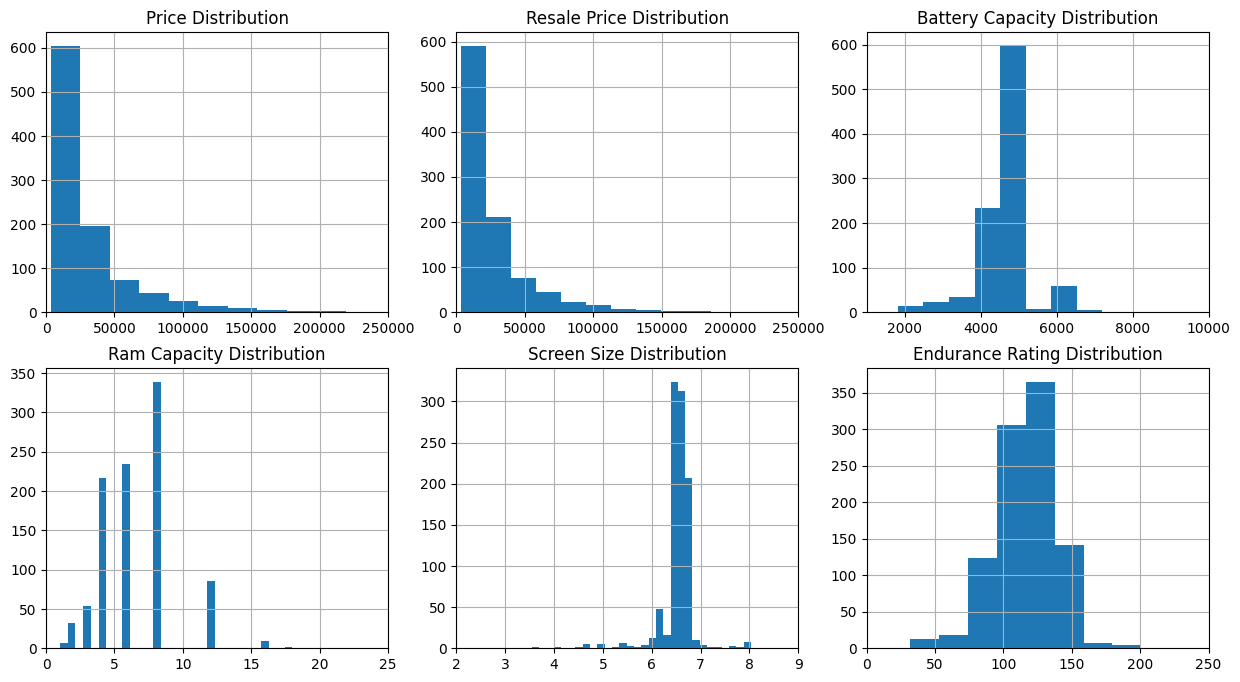

In [229]:
smartphone_df['temp_endurance_rating'] = smartphone_df['endurance_rating'].apply(convertToNumbers)

fig, axes = plt.subplots(2,3, figsize=(15,8))
axes = axes.flatten()

smartphone_df['price'].hist(bins=30, ax = axes[0])
axes[0].set_title('Price Distribution')
axes[0].set_xlim(0,250000)

smartphone_df['resale_price'].hist(bins=30, ax = axes[1])
axes[1].set_title('Resale Price Distribution')
axes[1].set_xlim(0,250000)

smartphone_df['battery_capacity'].hist(bins=30, ax = axes[2])
axes[2].set_title('Battery Capacity Distribution')
axes[2].set_xlim(1000,10000)

smartphone_df['ram_capacity'].hist(bins=30, ax = axes[3])
axes[3].set_title('Ram Capacity Distribution')
axes[3].set_xlim(0,25)

smartphone_df['screen_size'].hist(bins=30, ax = axes[4])
axes[4].set_title('Screen Size Distribution')
axes[4].set_xlim(2,9)

smartphone_df['temp_endurance_rating'].hist(bins=30, ax = axes[5])
axes[5].set_title('Endurance Rating Distribution')
axes[5].set_xlim(0,250)

smartphone_df.drop(columns=['temp_endurance_rating'], inplace=True)

These plots give a good overview of how some of the key features are distributed in the dataset. Both price and resale_price are heavily right-skewed, most smartphones fall into a more affordable range, with only a few high-end models driving the tail up. battery_capacity is centered around 5000 mAh, which seems to be a common standard. ram_capacity shows clear groupings, with 4 GB, 6 GB, and 8 GB being the most typical setups. As for screen_size, most phones are tightly packed between 6 and 7 inches, which aligns with modern smartphone trends. Finally, endurance_rating (after converting from strings to numbers) has a nice bell-shaped curve around 120 hours, showing that most phones land in a middle ground when it comes to battery longevity.



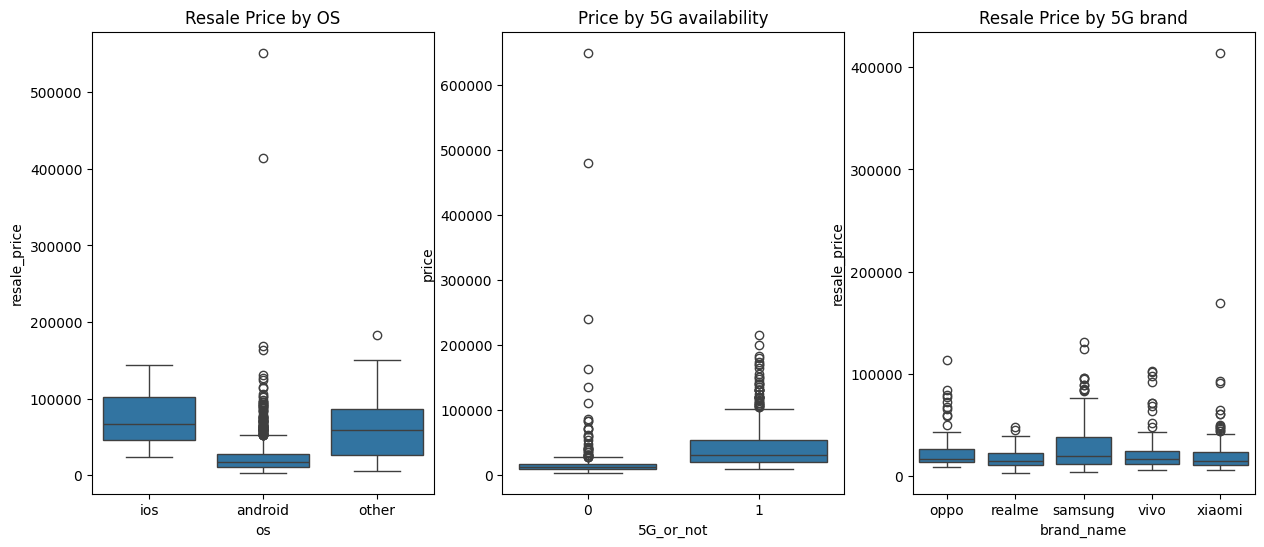

In [230]:
fig, axes = plt.subplots(1,3, figsize=(15,6))

sns.boxplot(x='os', y='resale_price', data= smartphone_df, ax=axes[0])
axes[0].set_title('Resale Price by OS')

sns.boxplot(x='5G_or_not', y='price', data= smartphone_df, ax=axes[1])
axes[1].set_title('Price by 5G availability')

top_brands = smartphone_df['brand_name'].value_counts().nlargest(5).index
filtered_df = smartphone_df[smartphone_df['brand_name'].isin(top_brands)]
sns.boxplot(x='brand_name', y='resale_price', data= filtered_df, ax=axes[2])
axes[2].set_title('Resale Price by 5G brand')

plt.show()

These boxplots highlight how resale price and original price vary across different categorical features. The first plot shows that iOS devices generally have higher resale prices than Android or other operating systems, though there's considerable spread across all categories. The second plot suggests that smartphones with 5G support tend to be priced higher than non-5G models, which aligns with expectations given their newer technology. In the third plot, which focuses on the top 5 most frequent brands, we see that brands like Samsung and Xiaomi show higher median resale prices compared to others, although there's still a wide range of values within each brand. These trends help confirm that categorical variables like OS, 5G availability, and brand may play a role in predicting resale value.

Text(0.5, 1.0, 'Endurance Rating vs Battery Capacity')

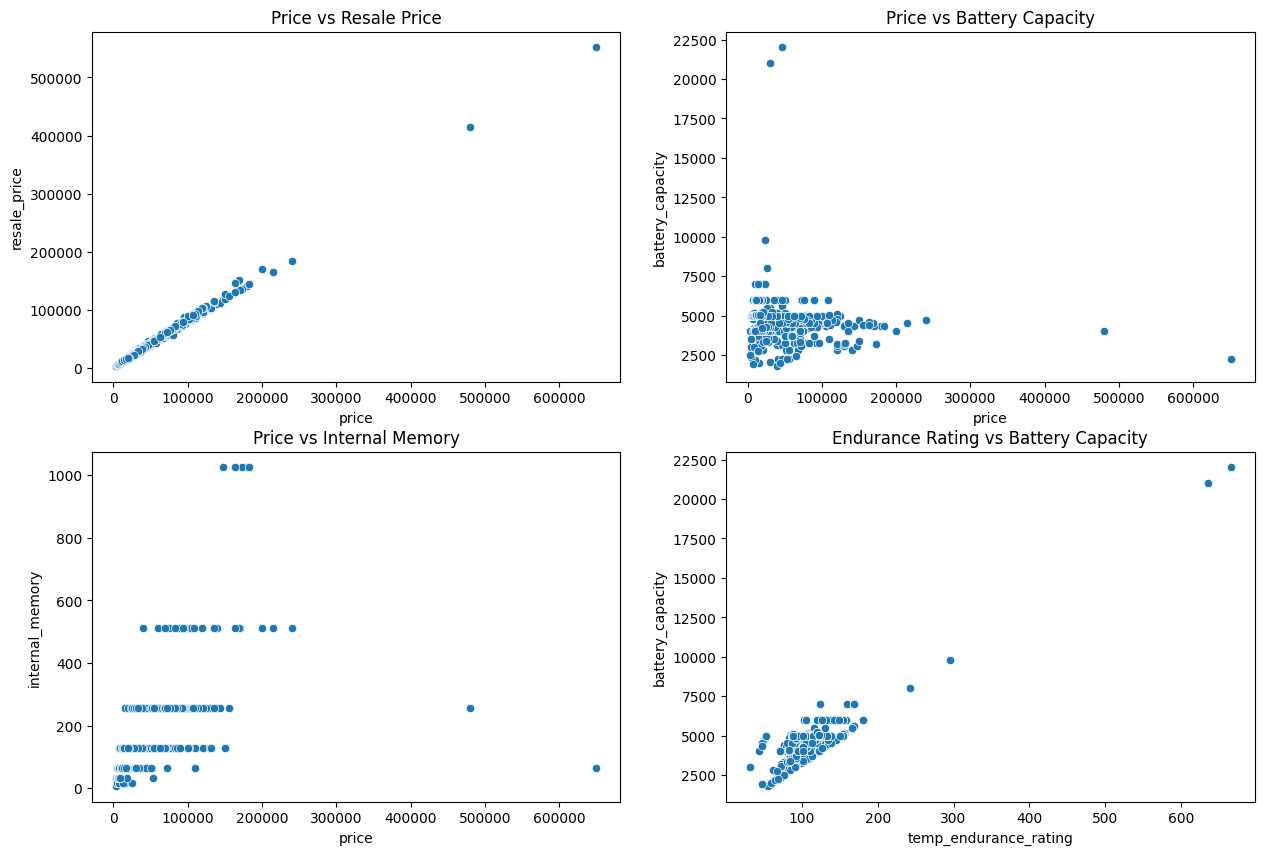

In [231]:
fig, axes = plt.subplots(2,2, figsize=(15,10))
axes = axes.flatten()

sns.scatterplot(x='price', y ='resale_price', data=smartphone_df, ax = axes[0])
axes[0].set_title('Price vs Resale Price')

sns.scatterplot(x='price', y ='battery_capacity', data=smartphone_df, ax = axes[1])
axes[1].set_title('Price vs Battery Capacity')

sns.scatterplot(x='price', y ='internal_memory', data=smartphone_df, ax = axes[2])
axes[2].set_title('Price vs Internal Memory')

smartphone_df['temp_endurance_rating'] = smartphone_df['endurance_rating'].apply(convertToNumbers)
sns.scatterplot(x='temp_endurance_rating', y ='battery_capacity', data=smartphone_df, ax = axes[3])
axes[3].set_title('Endurance Rating vs Battery Capacity')

These scatterplots give us a better sense of how some of the numeric features relate to each other. In the top-left, we see a strong and expected relationship between price and resale_price, pricier phones usually resell for more. On the top-right, there's no clear trend between price and battery_capacity, though a few expensive phones do seem to have big batteries. The bottom-left shows that phones with higher internal_memory can be more expensive, but it’s not a super strong pattern, a lot of phones cluster around common storage sizes. Lastly, battery_capacity and endurance_rating (bottom-right) do show a decent upward trend, which makes sense, in general, phones with bigger batteries tend to last longer, even if there’s some variation due to other factors like software efficiency or screen size.

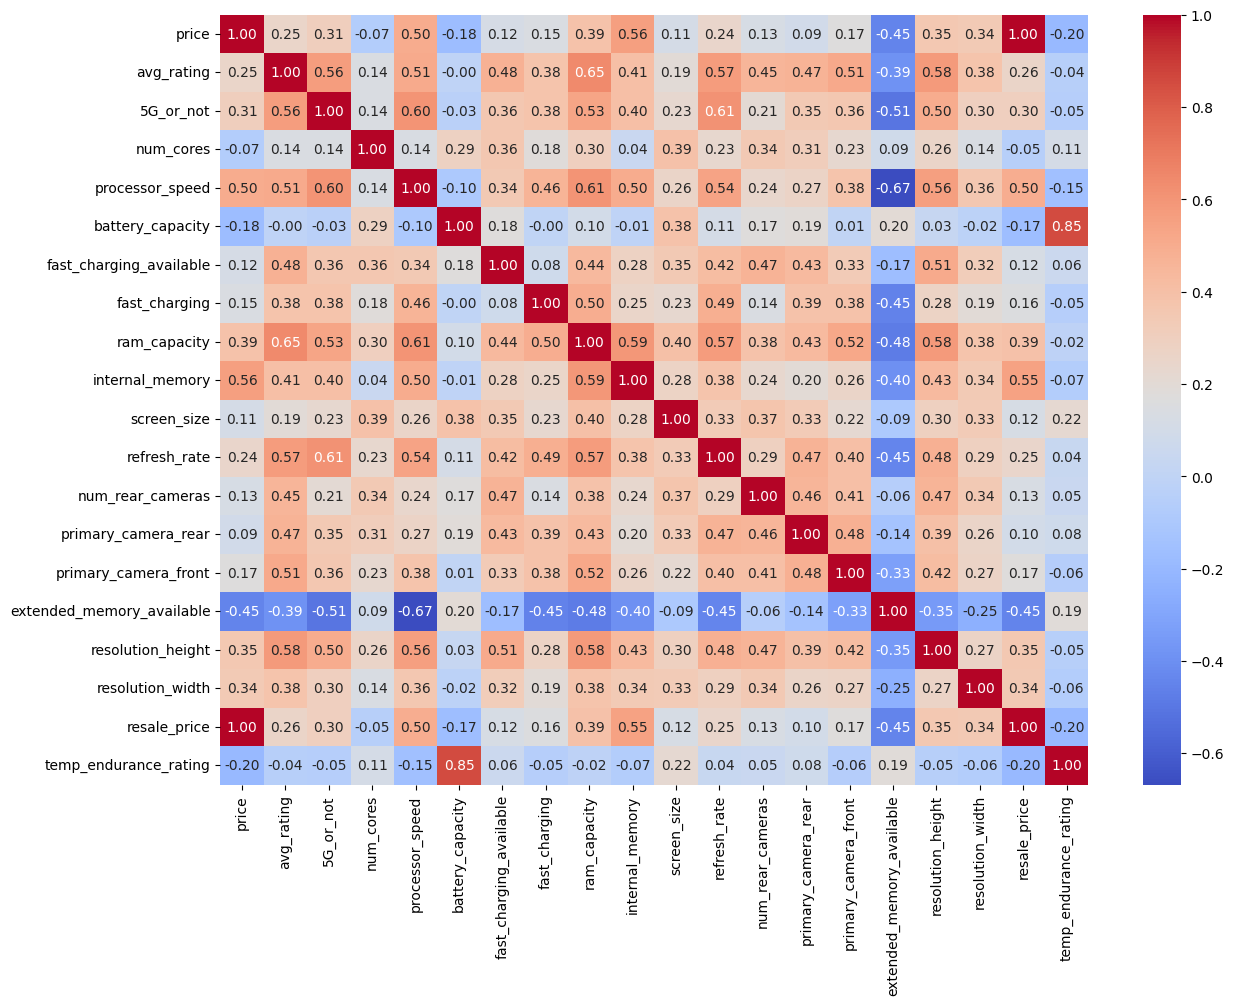

In [232]:
plt.figure(figsize=(14, 10))
correlation = smartphone_df.select_dtypes(include='number').corr()
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm")
smartphone_df.drop(columns=['temp_endurance_rating'], inplace=True)

This heatmap shows how the numeric features in the dataset are correlated with one another. As expected, there’s a strong correlation between price and resale_price, indicating that higher-priced phones tend to retain higher resale value. Features like ram_capacity, internal_memory, and screen_size show moderate positive correlations with price, while battery_capacity is more strongly correlated with temp_endurance_rating, which aligns with the idea that larger batteries often last longer. One standout is extended_memory_available, which negatively correlates with most numerical features, likely because budget phones often include microSD slots, while premium models don’t. Overall, this plot helps highlight which features move together and which might be informative for modeling.

Text(0.5, 1.0, 'Extended Memory Availability Distribution')

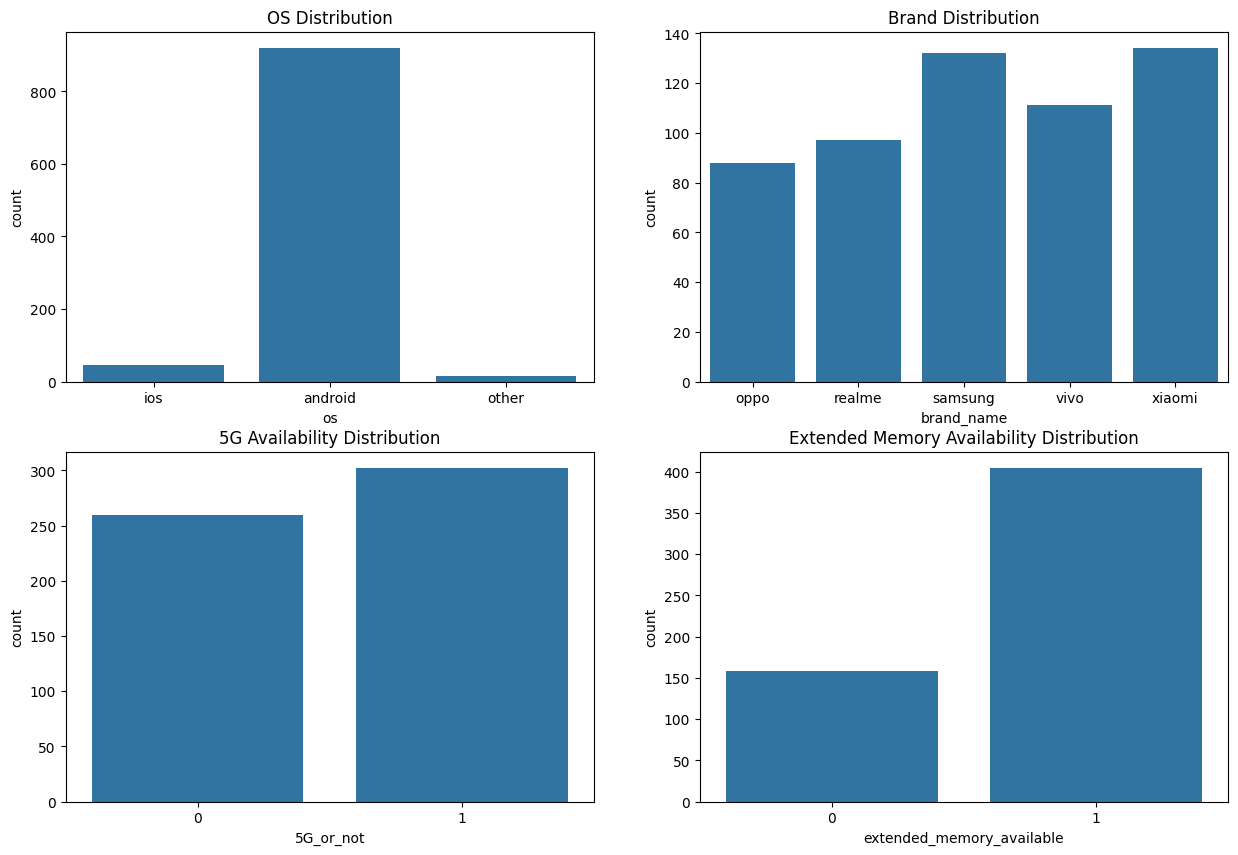

In [233]:
fig, axes = plt.subplots(2,2, figsize=(15,10))
axes = axes.flatten()

sns.countplot(data=smartphone_df, x='os', ax=axes[0])
axes[0].set_title('OS Distribution')
sns.countplot(data=filtered_df, x='brand_name', ax=axes[1])
axes[1].set_title('Brand Distribution')
sns.countplot(data=filtered_df, x='5G_or_not', ax=axes[2])
axes[2].set_title('5G Availability Distribution')
sns.countplot(data=filtered_df, x='extended_memory_available', ax=axes[3])
axes[3].set_title('Extended Memory Availability Distribution')


These bar plots show the distribution of some key categorical features in the dataset. Most smartphones in the dataset run Android, with only a small number using iOS or other systems. Among the top 5 brands, Xiaomi and Samsung appear most frequently, followed by Vivo, Realme, and Oppo. The 5G availability is relatively balanced, with a slightly higher number of phones supporting 5G. For extended memory (e.g., SD card slots), the majority of phones support it, though a significant portion do not, which could hint at differences between mid-range and flagship models.



<h2><b>Training models- Experimental Results </b> </h2>

In this part of the project, I’ll train and compare several machine learning models to predict smartphone price, resale value, and battery endurance. The chosen models cover a mix of classic, advanced, and interpretable approaches.I’ll implement a neural network (MLP) with embeddings to better capture relationships in categorical data, especially for features like brand and OS. I’ll include Random Forest as a reliable baseline due to its strong performance on structured data and built-in feature importance. XGBoost will be used for their gradient boosting capabilities, which often perform exceptionally well on tabular datasets and can capture complex, non-linear interactions between features. Bayesian Ridge Regression is included as a more probabilistic linear model that provides uncertainty estimation, which is rarely explored in this context.

I’m choosing these models instead of options like SVMs or k-NN because those tend to scale poorly with larger datasets or perform inconsistently on real-valued regression problems with many correlated inputs. To ensure the results are fair and reproducible, I’ll follow ML best practices: splitting the dataset into training, validation, and test sets, preventing data leakage, and tuning hyperparameters using only the validation set. Model performance will be evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared (R²) to capture both accuracy and robustness across the targets.

In [235]:
def set_seed(seed=42):
    """
    Sets the seed for reproducibility across Python, NumPy, and PyTorch.

    Parameters:
    -----------
    seed : int (default=42)
        The seed value to set across libraries for deterministic behavior.

    Returns:
    --------
    None

    Example:
    --------
    >>> set_seed(42)
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

The set_seed function sets a fixed seed for Python, NumPy, and PyTorch to improve the reproducibility of model results. While it helps make training more consistent, some models (like scikit-learn ones) may still require a random_state parameter for full reproducibility.


In [236]:
def splitting_data(dataset):
    """
    Splits the full dataset into training, validation, and test sets (80/16/20),
    and converts battery-related columns to numeric format.

    Parameters:
    -----------
    dataset : pd.DataFrame
        The full preprocessed smartphone dataset including features and targets.

    Returns:
    --------
    X_train : pd.DataFrame
        Training input features.
    X_val : pd.DataFrame
        Validation input features.
    X_test : pd.DataFrame
        Test input features.
    y_train : pd.DataFrame
        Training target values.
    y_val : pd.DataFrame
        Validation target values.
    y_test : pd.DataFrame
        Test target values.

    Example:
    --------
    >>> X_train, X_val, X_test, y_train, y_val, y_test = splitting_data(smartphone_df)
    """

    dataset = dataset.drop(columns=['model'])
    dataset['endurance_rating'] = dataset['endurance_rating'].apply(convertToNumbers)
    for col in ['talk_time', 'web_browsing', 'video_playback']:
      dataset[col] = dataset[col].apply(convertToMinutes)
    # Separate input features (X) from target values (y)
    X = dataset.drop(columns=['price', 'resale_price', 'endurance_rating', 'talk_time', 'web_browsing', 'video_playback'])
    y = dataset[['price', 'resale_price', 'endurance_rating', 'talk_time', 'web_browsing', 'video_playback']]

    # First split: training (80%) and test (20%)
    X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Second split: take part of training data and create a validation set (20% of 80% → 16%)
    X_train, X_val, y_train, y_val = sklearn.model_selection.train_test_split(
        X_train, y_train, test_size=0.2, random_state=42
    )

    # Return all six sets
    return X_train, X_val, X_test, y_train, y_val, y_test

# Run the split function and unpack the results
X_train, X_val, X_test, y_train, y_val, y_test = splitting_data(smartphone_df)



To prepare the data for training, we split the full dataset into three sets: training, validation, and test. First, we separate the input features (X) from the target values (y), which include all the values we want to predict. We then use an 80/20 split to hold out 20% of the data as a test set for final evaluation. From the remaining 80%, we take 20% again to create a validation set. This gives us a final split of 64% training, 16% validation, and 20% test. The validation set will be used to tune hyperparameters and monitor model performance during training, while the test set will stay untouched until the end to provide an unbiased estimate of how well the model generalizes.

I also dropped the model column from the feature set, as it has high cardinality and is unlikely to generalize well. Including it would risk overfitting and reduce the model's ability to learn from more meaningful attributes like brand, OS, or technical specifications.

To avoid data leakage, we ensure that all preprocessing steps like feature scaling or category indexing (e.g., for embeddings) will be fit only on the training set, and then applied to the validation and test sets. This way, no information from the test or validation sets leaks into the training process, which helps keep our evaluation realistic and fair.



<h3> Multilayer Perceptron <h3>

In [237]:
def prepare_inputs(X_train, X_val, X_test, categorical_columns, numeric_columns):
    """
    Prepares the data for models that require normalized numerical inputs and indexed categorical variables.
    Converts categorical features to indices and applies StandardScaler to numeric features.

    Parameters:
    -----------
    X_train : pd.DataFrame
        Training input data.
    X_val : pd.DataFrame
        Validation input data.
    X_test : pd.DataFrame
        Test input data.
    categorical_columns : list of str
        Column names of categorical features.
    numeric_columns : list of str
        Column names of numerical features.

    Returns:
    --------
    X_train : pd.DataFrame
        Processed training data with normalized numeric and indexed categorical features.
    X_val : pd.DataFrame
        Processed validation data.
    X_test : pd.DataFrame
        Processed test data.
    mappings : dict
        Mapping dictionaries from categorical values to integer indices.
    scaler : StandardScaler
        Fitted scaler object used for numeric normalization.

    Example:
    --------
    >>> X_train, X_val, X_test, mappings, scaler = prepare_inputs(X_train, X_val, X_test, categorical_columns, numeric_columns)
    """
    mappings = {}

    # -------- EMBEDDING: Convert categorical features to integer indices --------
    for col in categorical_columns:
        unique_values = X_train[col].dropna().unique()
        value_to_index = {val: idx + 1 for idx, val in enumerate(unique_values)}
        value_to_index['<unk>'] = 0  # unknown category index

        for df in [X_train, X_val, X_test]:
            df[f'{col}_idx'] = df[col].map(value_to_index).fillna(0).astype(int)

        mappings[col] = value_to_index

    # -------- SCALING: Normalize numerical features --------
    scaler = sklearn.preprocessing.StandardScaler()
    X_train[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
    X_val[numeric_columns] = scaler.transform(X_val[numeric_columns])
    X_test[numeric_columns] = scaler.transform(X_test[numeric_columns])

    return X_train, X_val, X_test, mappings, scaler

categorical_columns = ['brand_name', 'os', 'processor_brand']
numeric_columns = ['avg_rating','processor_speed', 'num_cores', 'refresh_rate', 'ram_capacity', 'internal_memory', 'battery_capacity', 'screen_size', 'fast_charging', 'resolution_height', 'resolution_width', 'primary_camera_rear', 'primary_camera_front']

X_train, X_val, X_test, mappings, scaler = prepare_inputs(
    X_train, X_val, X_test,
    categorical_columns=categorical_columns,
    numeric_columns=numeric_columns
)



Before feeding data into our MLP model, we need to make sure all inputs are in the right format and scale. This function handles that. First, it processes categorical features like brand and OS by converting them into integer indices that can be fed into embedding layers. Then, it takes care of battery-related columns, which were originally in string format (like "108h" or "4:30h"), and converts them into usable numeric values, for example, converting endurance rating into hours and talk time into total minutes. Finally, it normalizes all numerical features using StandardScaler to ensure they're on the same scale, which is crucial for models like MLP and Bayesian regression.


In [240]:
# Custom MLP model for regression tasks
class MLP(nn.Module):
    """
    A PyTorch Multi-Layer Perceptron (MLP) model for regression tasks with embedded categorical inputs.

    Parameters:
    -----------
    num_numeric_features : int
        Number of numeric features in the input.
    brand_vocab_size : int
        Vocabulary size for brand embeddings.
    os_vocab_size : int
        Vocabulary size for OS embeddings.
    processor_vocab_size : int
        Vocabulary size for processor embeddings.

    Example:
    --------
    >>> model = MLP(num_numeric_features=13, brand_vocab_size=50, os_vocab_size=10, processor_vocab_size=20)
    """
    def __init__(self, num_numeric_features, brand_vocab_size, os_vocab_size, processor_vocab_size):
        super().__init__()

        # Embedding layers for categorical features
        self.brand_embedding = nn.Embedding(brand_vocab_size, 16)     # Each brand becomes a 16-dim vector
        self.os_embedding = nn.Embedding(os_vocab_size, 4)            # Each OS becomes a 4-dim vector
        self.processor_embedding = nn.Embedding(processor_vocab_size, 8)  # Each processor becomes an 8-dim vector

        # Total input size = numeric features + embedding outputs
        input_dim = num_numeric_features + 16 + 4 + 8

        # Define the actual MLP (fully connected layers)
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 128),  # First hidden layer
            nn.ReLU(),
            nn.Linear(128, 64),         # Second hidden layer
            nn.ReLU(),
            nn.Linear(64, 1)            # Output layer (predicting 1 value)
        )

    def forward(self, x_numeric, brand_idx, os_idx, processor_idx):
        """
        Forward pass through the network.

        Parameters:
        -----------
        x_numeric : torch.Tensor
            Tensor containing numeric features.
        brand_idx : torch.Tensor
            Tensor with index values for brand_name.
        os_idx : torch.Tensor
            Tensor with index values for OS.
        processor_idx : torch.Tensor
            Tensor with index values for processor brand.

        Returns:
        --------
        torch.Tensor
            Predicted regression output for each input sample.
        """
        # Look up embeddings for categorical inputs
        brand_embedding = self.brand_embedding(brand_idx)
        os_embedding = self.os_embedding(os_idx)
        processor_embedding = self.processor_embedding(processor_idx)

        # Concatenate numeric and embedded features
        x = torch.cat([x_numeric, brand_embedding, os_embedding, processor_embedding], dim=1)

        # Feed through the MLP
        return self.mlp(x)

This class defines the structure of the MLP model that we’ll use for regression tasks like predicting smartphone price or battery life. It takes two types of inputs: numerical features (e.g., RAM, battery size) and categorical features (e.g., brand, OS, processor). For the categorical inputs, it uses torch.nn.Embedding layers to map each category (like a specific brand) into a dense vector. These embeddings are then combined with the normalized numerical features and passed through a small feedforward neural network (MLP) with two hidden layers. The final output is a single prediction value. This structure allows the model to learn complex patterns while also capturing semantic relationships between categories using embeddings.

We chose two hidden layers with 128 and 64 neurons to keep the architecture simple but expressive enough to learn non-linear relationships in the data. ReLU was used as the activation function due to its general reliability and efficiency in training deeper networks.

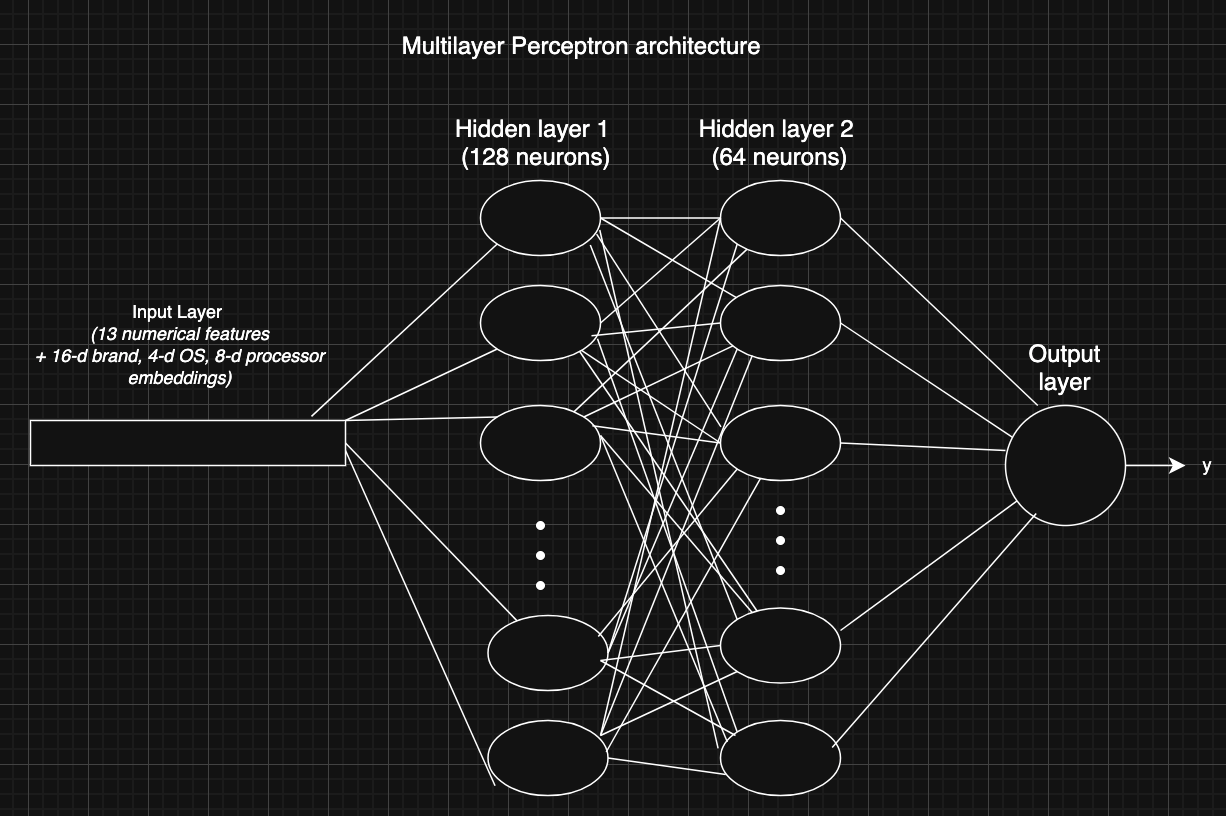

This diagram illustrates the architecture of the Multilayer Perceptron (MLP) used in the project. The input layer combines 13 normalized numerical features with three embedding vectors (16-dim brand, 4-dim OS, and 8-dim processor), which are passed through two hidden layers with 128 and 64 neurons respectively. ReLU activation is applied between layers to introduce non-linearity, helping the model capture complex patterns in the data.

In [241]:
def build_dataloaders_for_target(X_train, X_val, y_train, y_val, numeric_columns, target_col):
    """
    Builds PyTorch DataLoaders for the specified regression target.

    Parameters:
    -----------
    X_train, X_val : pd.DataFrame
        Input features for training and validation sets.
    y_train, y_val : pd.DataFrame
        Target values for training and validation sets.
    numeric_columns : list of str
        Names of numeric columns used as inputs.
    target_col : str
        Name of the target column to predict.

    Returns:
    --------
    train_loader : torch.utils.data.DataLoader
        DataLoader for training data.
    val_loader : torch.utils.data.DataLoader
        DataLoader for validation data.

    Example:
    --------
    >>> train_loader, val_loader = build_dataloaders_for_target(X_train, X_val, y_train, y_val, numeric_columns, 'price')
    """

    # Numeric input
    x_train_numeric = torch.tensor(X_train[numeric_columns].values, dtype=torch.float32)
    x_val_numeric = torch.tensor(X_val[numeric_columns].values, dtype=torch.float32)

    # Embedding indices
    brand_train_idx = torch.tensor(X_train['brand_name_idx'].values, dtype=torch.long)
    os_train_idx = torch.tensor(X_train['os_idx'].values, dtype=torch.long)
    proc_train_idx = torch.tensor(X_train['processor_brand_idx'].values, dtype=torch.long)

    brand_val_idx = torch.tensor(X_val['brand_name_idx'].values, dtype=torch.long)
    os_val_idx = torch.tensor(X_val['os_idx'].values, dtype=torch.long)
    proc_val_idx = torch.tensor(X_val['processor_brand_idx'].values, dtype=torch.long)

    # Target (can be any column)
    y_train_target = torch.tensor(y_train[target_col].values, dtype=torch.float32).view(-1, 1)
    y_val_target = torch.tensor(y_val[target_col].values, dtype=torch.float32).view(-1, 1)

    # Datasets and Loaders
    train_dataset = torch.utils.data.TensorDataset(x_train_numeric, brand_train_idx, os_train_idx, proc_train_idx, y_train_target)
    val_dataset = torch.utils.data.TensorDataset(x_val_numeric, brand_val_idx, os_val_idx, proc_val_idx, y_val_target)

    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32)

    return train_loader, val_loader


The function above (build_dataloaders_for_target) prepares the training and validation data for the MLP model by converting the cleaned DataFrames into PyTorch tensors. It extracts the numeric features, categorical indices (for embeddings), and the target price, then wraps them into TensorDataset objects. These datasets are passed to PyTorch DataLoaders, which handle batching and shuffling during training. This structure ensures the model receives data in the correct format and allows for efficient batch-wise updates during the training loop.

In the function below (train_mlp_model), I train a Multi-Layer Perceptron (MLP) model to predict each of the six target variables individually: price, resale price, endurance rating, talk time, web browsing time, and video playback time. For each target, a new instance of the MLP is created and trained using PyTorch DataLoaders that combine 13 normalized numeric features with categorical embeddings for brand, OS, and processor. The model is trained for 25 epochs, which provides enough iterations for the weights to converge without excessive overfitting. I use the Adam optimizer, a popular choice for deep learning tasks, which adapts learning rates during training and helps with faster and more stable convergence. The learning rate is set to 0.001, a common default that balances training speed and stability.

The loss function used is Mean Squared Error (MSE), suitable for regression problems where we want to minimize the squared difference between predicted and true values. During training, I track both training and validation losses at each epoch, which are then plotted to observe trends like improvement, convergence, or signs of overfitting. The looped structure allows for reuse of the training logic across all target variables while keeping the model and predictions specific to each task.

[price] Epoch 1/25 | Train Loss: 2808093718.4000 | Val Loss: 2360086348.8000
[price] Epoch 2/25 | Train Loss: 2883356764.8000 | Val Loss: 2359501107.2000
[price] Epoch 3/25 | Train Loss: 2819321598.4000 | Val Loss: 2357884262.4000
[price] Epoch 4/25 | Train Loss: 2802020553.6000 | Val Loss: 2353904486.4000
[price] Epoch 5/25 | Train Loss: 2809864870.4000 | Val Loss: 2345753190.4000
[price] Epoch 6/25 | Train Loss: 2779453715.2000 | Val Loss: 2330761241.6000
[price] Epoch 7/25 | Train Loss: 2759802652.8000 | Val Loss: 2305732864.0000
[price] Epoch 8/25 | Train Loss: 2738370320.0000 | Val Loss: 2266556723.2000
[price] Epoch 9/25 | Train Loss: 2711117590.4000 | Val Loss: 2210688512.0000
[price] Epoch 10/25 | Train Loss: 2643604256.0000 | Val Loss: 2132942464.0000
[price] Epoch 11/25 | Train Loss: 2565927913.6000 | Val Loss: 2032817356.8000
[price] Epoch 12/25 | Train Loss: 2489311313.6000 | Val Loss: 1907361280.0000
[price] Epoch 13/25 | Train Loss: 2366071824.0000 | Val Loss: 1758068480.

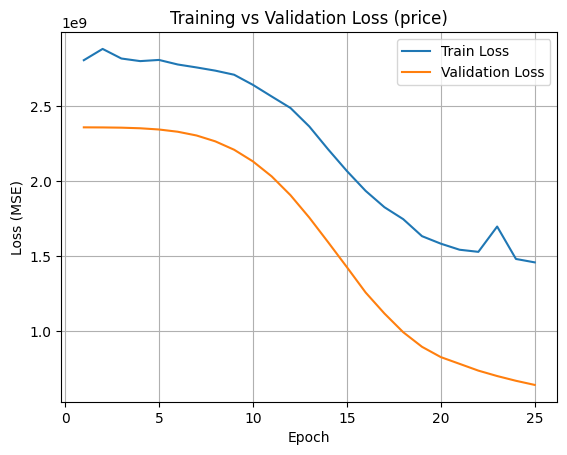

[resale_price] Epoch 1/25 | Train Loss: 1974252505.6000 | Val Loss: 1595094169.6000
[resale_price] Epoch 2/25 | Train Loss: 1968810720.0000 | Val Loss: 1594641177.6000
[resale_price] Epoch 3/25 | Train Loss: 1968964726.4000 | Val Loss: 1593330432.0000
[resale_price] Epoch 4/25 | Train Loss: 1955934662.4000 | Val Loss: 1590161766.4000
[resale_price] Epoch 5/25 | Train Loss: 1975194283.2000 | Val Loss: 1583789363.2000
[resale_price] Epoch 6/25 | Train Loss: 1945367225.6000 | Val Loss: 1571501926.4000
[resale_price] Epoch 7/25 | Train Loss: 1944819568.0000 | Val Loss: 1551115904.0000
[resale_price] Epoch 8/25 | Train Loss: 1929580268.8000 | Val Loss: 1519721036.8000
[resale_price] Epoch 9/25 | Train Loss: 1903261603.2000 | Val Loss: 1474388121.6000
[resale_price] Epoch 10/25 | Train Loss: 1832967488.0000 | Val Loss: 1413379737.6000
[resale_price] Epoch 11/25 | Train Loss: 1764833672.0000 | Val Loss: 1334354457.6000
[resale_price] Epoch 12/25 | Train Loss: 1699947654.4000 | Val Loss: 12413

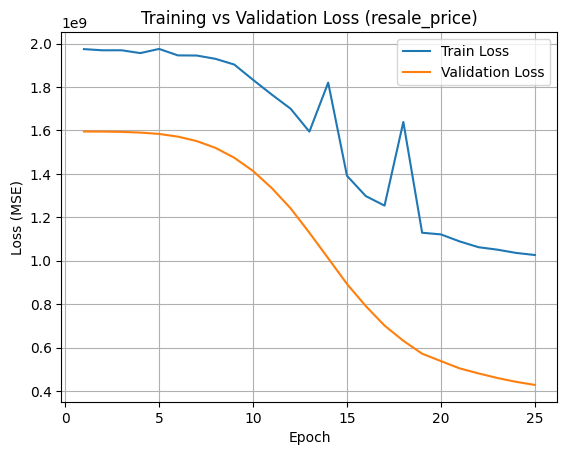

[endurance_rating] Epoch 1/25 | Train Loss: 15382.7683 | Val Loss: 13095.9289
[endurance_rating] Epoch 2/25 | Train Loss: 14489.1412 | Val Loss: 11738.7246
[endurance_rating] Epoch 3/25 | Train Loss: 12175.5788 | Val Loss: 8502.5323
[endurance_rating] Epoch 4/25 | Train Loss: 7547.2776 | Val Loss: 3717.9419
[endurance_rating] Epoch 5/25 | Train Loss: 3156.6735 | Val Loss: 1535.4318
[endurance_rating] Epoch 6/25 | Train Loss: 2105.0103 | Val Loss: 1151.3032
[endurance_rating] Epoch 7/25 | Train Loss: 1696.7335 | Val Loss: 895.8991
[endurance_rating] Epoch 8/25 | Train Loss: 1390.6486 | Val Loss: 720.1578
[endurance_rating] Epoch 9/25 | Train Loss: 1159.9499 | Val Loss: 606.0527
[endurance_rating] Epoch 10/25 | Train Loss: 1168.3972 | Val Loss: 524.4044
[endurance_rating] Epoch 11/25 | Train Loss: 863.8669 | Val Loss: 478.1594
[endurance_rating] Epoch 12/25 | Train Loss: 754.8583 | Val Loss: 424.5844
[endurance_rating] Epoch 13/25 | Train Loss: 674.1337 | Val Loss: 409.0657
[endurance_ra

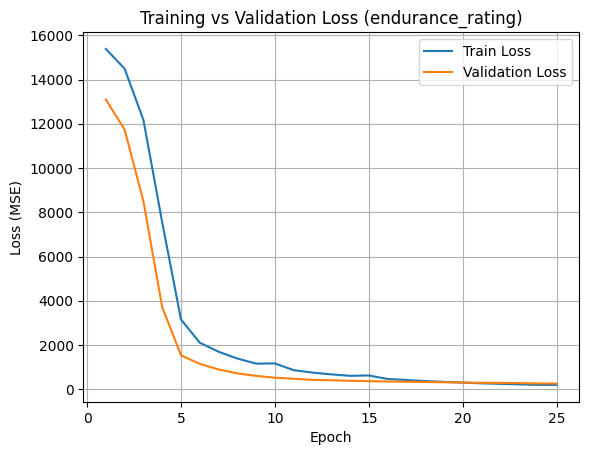

[talk_time] Epoch 1/25 | Train Loss: 3915937.5625 | Val Loss: 3572544.2000
[talk_time] Epoch 2/25 | Train Loss: 3896306.5750 | Val Loss: 3534424.0500
[talk_time] Epoch 3/25 | Train Loss: 3815676.5125 | Val Loss: 3423972.2000
[talk_time] Epoch 4/25 | Train Loss: 3624438.6500 | Val Loss: 3165607.1000
[talk_time] Epoch 5/25 | Train Loss: 3243301.0375 | Val Loss: 2672795.0500
[talk_time] Epoch 6/25 | Train Loss: 2548189.7313 | Val Loss: 1913968.6750
[talk_time] Epoch 7/25 | Train Loss: 1642469.6656 | Val Loss: 1055815.4500
[talk_time] Epoch 8/25 | Train Loss: 813989.7891 | Val Loss: 462680.4188
[talk_time] Epoch 9/25 | Train Loss: 405607.5914 | Val Loss: 281844.5781
[talk_time] Epoch 10/25 | Train Loss: 314359.0312 | Val Loss: 235904.4281
[talk_time] Epoch 11/25 | Train Loss: 277507.3605 | Val Loss: 208047.4062
[talk_time] Epoch 12/25 | Train Loss: 249354.2297 | Val Loss: 188437.8594
[talk_time] Epoch 13/25 | Train Loss: 228664.0168 | Val Loss: 173625.0891
[talk_time] Epoch 14/25 | Train L

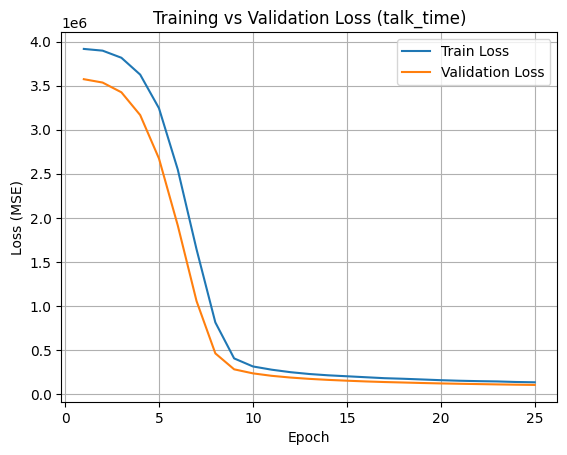

[web_browsing] Epoch 1/25 | Train Loss: 1208440.7812 | Val Loss: 1050469.7375
[web_browsing] Epoch 2/25 | Train Loss: 1200357.7063 | Val Loss: 1038570.3625
[web_browsing] Epoch 3/25 | Train Loss: 1218977.0000 | Val Loss: 1002553.4250
[web_browsing] Epoch 4/25 | Train Loss: 1113414.0094 | Val Loss: 916245.5375
[web_browsing] Epoch 5/25 | Train Loss: 981547.8375 | Val Loss: 751838.1875
[web_browsing] Epoch 6/25 | Train Loss: 754845.8625 | Val Loss: 513768.7625
[web_browsing] Epoch 7/25 | Train Loss: 486778.3211 | Val Loss: 284764.6937
[web_browsing] Epoch 8/25 | Train Loss: 295884.5605 | Val Loss: 181371.7625
[web_browsing] Epoch 9/25 | Train Loss: 238502.2031 | Val Loss: 156547.3500
[web_browsing] Epoch 10/25 | Train Loss: 218490.4820 | Val Loss: 139477.7328
[web_browsing] Epoch 11/25 | Train Loss: 201004.8164 | Val Loss: 125702.7234
[web_browsing] Epoch 12/25 | Train Loss: 189247.4104 | Val Loss: 114377.1156
[web_browsing] Epoch 13/25 | Train Loss: 178665.4926 | Val Loss: 104681.2016
[

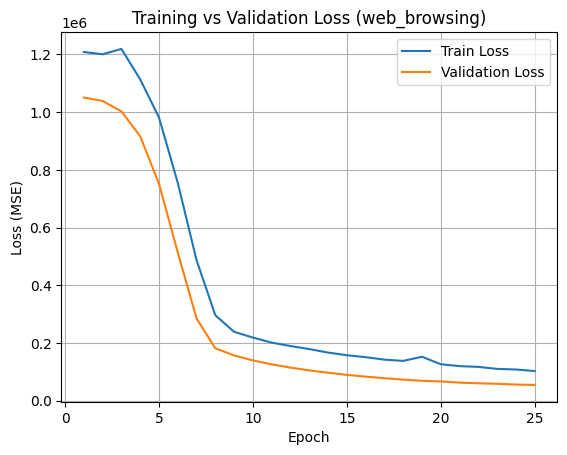

[video_playback] Epoch 1/25 | Train Loss: 1651272.3062 | Val Loss: 1393586.1750
[video_playback] Epoch 2/25 | Train Loss: 1629522.1438 | Val Loss: 1374579.2500
[video_playback] Epoch 3/25 | Train Loss: 1606610.1687 | Val Loss: 1317771.5750
[video_playback] Epoch 4/25 | Train Loss: 1498964.8562 | Val Loss: 1182578.4750
[video_playback] Epoch 5/25 | Train Loss: 1295985.6687 | Val Loss: 931342.3125
[video_playback] Epoch 6/25 | Train Loss: 967758.4313 | Val Loss: 590922.2750
[video_playback] Epoch 7/25 | Train Loss: 598365.9570 | Val Loss: 311430.1375
[video_playback] Epoch 8/25 | Train Loss: 380294.5375 | Val Loss: 223399.1187
[video_playback] Epoch 9/25 | Train Loss: 322923.5922 | Val Loss: 193994.4062
[video_playback] Epoch 10/25 | Train Loss: 290020.5941 | Val Loss: 166957.5953
[video_playback] Epoch 11/25 | Train Loss: 267574.0402 | Val Loss: 145536.8438
[video_playback] Epoch 12/25 | Train Loss: 251748.9965 | Val Loss: 130399.9453
[video_playback] Epoch 13/25 | Train Loss: 230107.17

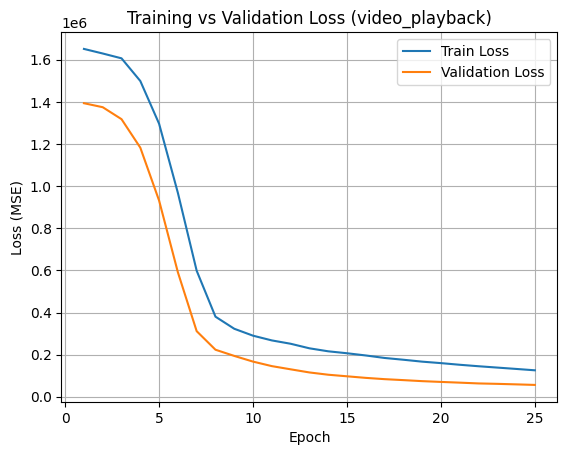

In [242]:
# ---------------------- Training Loop with Plot ----------------------
def train_mlp_model(model, train_loader, val_loader, target_name, num_epochs=25, lr=0.001):
    """
    Trains a given MLP model on the specified target variable and plots the training/validation losses.

    Parameters:
    -----------
    model : torch.nn.Module
        The MLP model to train.
    train_loader, val_loader : DataLoader
        PyTorch DataLoaders for training and validation sets.
    target_name : str
        The name of the target variable (e.g., 'price').
    num_epochs : int
        Number of training epochs. Default is 25.
    lr : float
        Learning rate for the optimizer. Default is 0.001.

    Returns:
    --------
    None

    Example:
    --------
    >>> train_mlp_model(model, train_loader, val_loader, target_name='price', num_epochs=25)
    """
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        total_train_loss = 0

        for x_num, b_idx, o_idx, p_idx, y in train_loader:
            optimizer.zero_grad()
            preds = model(x_num, b_idx, o_idx, p_idx)
            loss = criterion(preds, y)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for x_num, b_idx, o_idx, p_idx, y in val_loader:
                preds = model(x_num, b_idx, o_idx, p_idx)
                loss = criterion(preds, y)
                total_val_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        avg_val_loss = total_val_loss / len(val_loader)
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        print(f"[{target_name}] Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # -------- Plotting --------
    plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss')
    plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss (MSE)")
    plt.title(f"Training vs Validation Loss ({target_name})")
    plt.legend()
    plt.grid(True)
    plt.show()


# ---------------------- Train MLP for Each Target ----------------------
def safe_to_float_tensor(series):
    """Converts a Pandas Series of object or mixed types to float32 safely."""
    return torch.tensor(pd.to_numeric(series, errors='coerce').fillna(0).values, dtype=torch.float32).view(-1, 1)


targets = ['price', 'resale_price', 'endurance_rating', 'talk_time', 'web_browsing', 'video_playback']

for target in targets:
    model = MLP(
        num_numeric_features=13,
        brand_vocab_size=len(mappings['brand_name']),
        os_vocab_size=len(mappings['os']),
        processor_vocab_size=len(mappings['processor_brand'])
    )


    train_loader, val_loader = build_dataloaders_for_target(
        X_train, X_val, y_train, y_val,
        numeric_columns=numeric_columns,
        target_col = target
    )

    train_mlp_model(model, train_loader, val_loader, target_name=target, num_epochs=25, lr=0.001)



The MLP model showed consistent improvements across all six target variables: price, resale_price, endurance_rating, talk_time, web_browsing, and video_playback. For targets with higher variance like price and resale_price, the training began with relatively large losses, but both training and validation errors gradually decreased over the epochs, suggesting that the model was able to learn useful patterns from the data. For other targets such as endurance_rating and usage durations, the loss curves dropped more quickly in the early stages of training and continued to improve at a steady pace.

Throughout training, validation loss remained slightly below the training loss for most targets. While this is generally seen as a good sign, it may also reflect aspects like early stopping or regularization effects that reduce variance in the validation set. These trends suggest that the model was not clearly overfitting and was able to generalize reasonably during training and validation.

Overall, while these results don’t guarantee strong performance on unseen data, the training behavior indicates that the MLP was able to fit the data well and remained stable across different regression tasks in the dataset.

In [243]:
# ---------------------- Test Evaluation Function ----------------------
def evaluate_on_test(model, test_loader, target_name):
    """
    Evaluates a trained PyTorch model on the test set and prints MAE, RMSE, and R².

    Parameters:
    -----------
    model : torch.nn.Module
        Trained PyTorch model.
    test_loader : torch.utils.data.DataLoader
        DataLoader for test data.
    target_name : str
        Name of the target variable (e.g., 'price').

    Returns:
    --------
    dict
        Dictionary containing MAE, RMSE, and R² metrics.

    Example:
    --------
    >>> evaluate_on_test(model, test_loader, target_name='price')
    """
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for x_num, b_idx, o_idx, p_idx, y in test_loader:
            preds = model(x_num, b_idx, o_idx, p_idx)
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    # Flatten arrays for metric functions
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    mae = sklearn.metrics.mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(sklearn.metrics.mean_squared_error(y_true, y_pred))
    r2 = sklearn.metrics.r2_score(y_true, y_pred)

    print(f"[{target_name}] Test MAE: {mae:.2f} | RMSE: {rmse:.2f} | R²: {r2:.2f}")
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

# ---------------------- Test Evaluation for All Targets ----------------------
test_results = {}

for target in targets:
    model = MLP(
        num_numeric_features=13,
        brand_vocab_size=len(mappings['brand_name']),
        os_vocab_size=len(mappings['os']),
        processor_vocab_size=len(mappings['processor_brand'])
    )

    test_loader = build_dataloaders_for_target(
        X_test, X_test, y_test, y_test,
        numeric_columns=numeric_columns,
        target_col=target
    )[0]

    test_results[target] = evaluate_on_test(model, test_loader, target_name=target)


[price] Test MAE: 32507.95 | RMSE: 46143.60 | R²: -0.99
[resale_price] Test MAE: 27478.54 | RMSE: 38407.19 | R²: -1.05
[endurance_rating] Test MAE: 116.22 | RMSE: 118.36 | R²: -26.93
[talk_time] Test MAE: 1887.97 | RMSE: 1934.18 | R²: -20.19
[web_browsing] Test MAE: 1004.77 | RMSE: 1034.55 | R²: -16.62
[video_playback] Test MAE: 1158.46 | RMSE: 1195.58 | R²: -15.36


<h4> Test loss analysis <h4>

Looking at the test results of our MLP model, we can see that it struggles to make accurate predictions, especially for the main targets like price and resale_price. The MAE values for these are around 32K and 27K, which means the average prediction error is pretty large, not ideal for a pricing task. The RMSE values are even higher (over 46K and 38K), showing that there are some really big individual errors in the predictions. The R² scores are also very negative (around -1), meaning the model performs worse than just predicting the average price every time, so it’s clearly not capturing the patterns very well.

For battery-related metrics like endurance_rating, talk_time, web_browsing, and video_playback, the model does even worse. The errors (MAE and RMSE) are still high relative to the scale of those targets, and the R² scores are extremely low, like -27 for endurance, which means the model didn’t learn anything useful for these tasks.

Overall, even though the MLP seemed to improve during training, it doesn’t generalize well to the test set. This could be due to overfitting or just not being the right model architecture for these kinds of predictions.

To counter these inacurracies, we will try to add regularization techniques (like dropout) or change the architecture of the MLP (like changing the numbers of neurons or the activation functions). We will then verify if results improve.

In [244]:
# Modifying MLP model for regression tasks
class MLP(nn.Module):
    def __init__(self, num_numeric_features, brand_vocab_size, os_vocab_size, processor_vocab_size):
        super().__init__()

        # Embedding layers for categorical features
        self.brand_embedding = nn.Embedding(brand_vocab_size, 16)     # Each brand becomes a 16-dim vector
        self.os_embedding = nn.Embedding(os_vocab_size, 4)            # Each OS becomes a 4-dim vector
        self.processor_embedding = nn.Embedding(processor_vocab_size, 8)  # Each processor becomes an 8-dim vector

        # Total input size = numeric features + embedding outputs
        input_dim = num_numeric_features + 16 + 4 + 8

        # Define the actual MLP (fully connected layers)
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 32),  # First hidden layer, changed output neurons from 128 to 64
            nn.LeakyReLU(), # Changed activation function from Relu to LeakyRelu
            nn.Dropout(0.4), # Added dropout
            nn.Linear(32, 16),    # Second hidden layer, changed output neurons from 64 to 32
            nn.LeakyReLU(), # Changed activation function from Relu to LeakyRelu
            nn.Dropout(0.4), # Added dropout
            nn.Linear(16, 1)     # Output layer (predicting 1 value)
        )

    def forward(self, x_numeric, brand_idx, os_idx, processor_idx):
        # Look up embeddings for categorical inputs
        brand_embedding = self.brand_embedding(brand_idx)
        os_embedding = self.os_embedding(os_idx)
        processor_embedding = self.processor_embedding(processor_idx)

        # Concatenate numeric and embedded features
        x = torch.cat([x_numeric, brand_embedding, os_embedding, processor_embedding], dim=1)

        # Feed through the MLP
        return self.mlp(x)

To help reduce overfitting in our MLP model, we made several architecture adjustments. First, we reduced the number of neurons in both hidden layers (from 128→32 and 64→16), which lowers the model’s capacity and prevents it from memorizing training data too closely. We also replaced ReLU with LeakyReLU as the activation function, which helps maintain gradient flow for negative inputs and reduces the risk of inactive neurons. Finally, we introduced Dropout layers (with a rate of 0.4) after each hidden layer to randomly deactivate neurons during training, forcing the model to learn more robust features and improving its generalization to unseen data. Finally, we applied weight decay (L2 regularization) with a value of 1e-5 in the optimizer, which penalizes large weights and helps prevent the model from overfitting the training data.

[price] Epoch 1/25 | Train Loss: 2801480654.4000 | Val Loss: 2360262528.0000
[price] Epoch 2/25 | Train Loss: 2824634806.4000 | Val Loss: 2360236364.8000
[price] Epoch 3/25 | Train Loss: 2811359990.4000 | Val Loss: 2360186188.8000
[price] Epoch 4/25 | Train Loss: 2818655734.4000 | Val Loss: 2360088627.2000
[price] Epoch 5/25 | Train Loss: 2812459923.2000 | Val Loss: 2359909478.4000
[price] Epoch 6/25 | Train Loss: 2801167033.6000 | Val Loss: 2359595443.2000
[price] Epoch 7/25 | Train Loss: 2842902720.0000 | Val Loss: 2359037312.0000
[price] Epoch 8/25 | Train Loss: 2826630684.8000 | Val Loss: 2358062745.6000
[price] Epoch 9/25 | Train Loss: 2809848416.0000 | Val Loss: 2356450278.4000
[price] Epoch 10/25 | Train Loss: 2822308688.0000 | Val Loss: 2353976243.2000
[price] Epoch 11/25 | Train Loss: 2799079680.0000 | Val Loss: 2350310707.2000
[price] Epoch 12/25 | Train Loss: 2788976208.0000 | Val Loss: 2345237094.4000
[price] Epoch 13/25 | Train Loss: 2790485241.6000 | Val Loss: 2338500224.

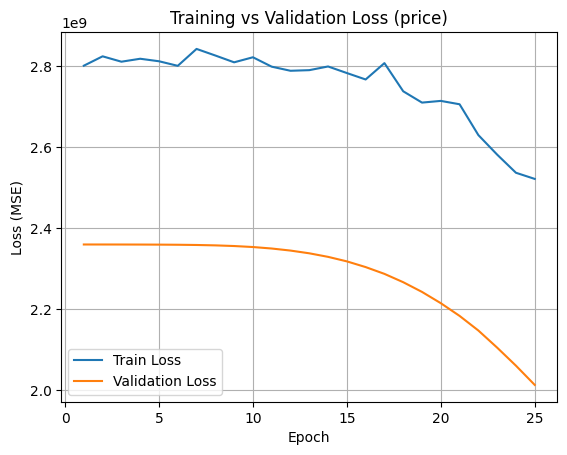

[resale_price] Epoch 1/25 | Train Loss: 1989083504.0000 | Val Loss: 1595227929.6000
[resale_price] Epoch 2/25 | Train Loss: 1990965923.2000 | Val Loss: 1595190707.2000
[resale_price] Epoch 3/25 | Train Loss: 1956720347.2000 | Val Loss: 1595101516.8000
[resale_price] Epoch 4/25 | Train Loss: 1972124648.0000 | Val Loss: 1594904192.0000
[resale_price] Epoch 5/25 | Train Loss: 1972012435.2000 | Val Loss: 1594493670.4000
[resale_price] Epoch 6/25 | Train Loss: 1967069464.0000 | Val Loss: 1593712179.2000
[resale_price] Epoch 7/25 | Train Loss: 1960083579.2000 | Val Loss: 1592404531.2000
[resale_price] Epoch 8/25 | Train Loss: 1958473673.6000 | Val Loss: 1590302310.4000
[resale_price] Epoch 9/25 | Train Loss: 1953721785.6000 | Val Loss: 1587075251.2000
[resale_price] Epoch 10/25 | Train Loss: 1968441729.6000 | Val Loss: 1582664908.8000
[resale_price] Epoch 11/25 | Train Loss: 1963215526.4000 | Val Loss: 1576372300.8000
[resale_price] Epoch 12/25 | Train Loss: 1951482838.4000 | Val Loss: 15677

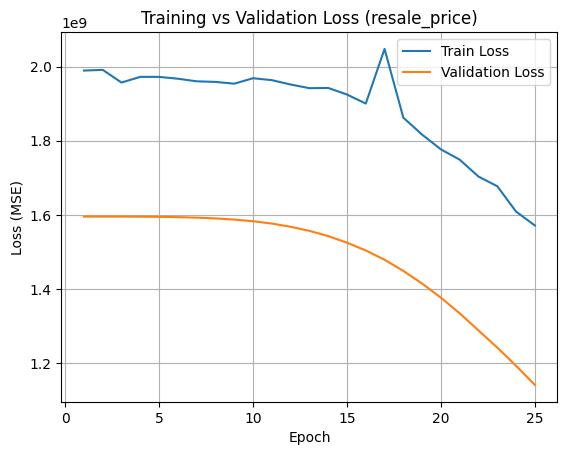

[endurance_rating] Epoch 1/25 | Train Loss: 15580.2490 | Val Loss: 13563.1439
[endurance_rating] Epoch 2/25 | Train Loss: 15530.3856 | Val Loss: 13502.5328
[endurance_rating] Epoch 3/25 | Train Loss: 15396.9132 | Val Loss: 13370.7596
[endurance_rating] Epoch 4/25 | Train Loss: 15227.4661 | Val Loss: 13069.4848
[endurance_rating] Epoch 5/25 | Train Loss: 14746.3509 | Val Loss: 12436.0094
[endurance_rating] Epoch 6/25 | Train Loss: 13679.0772 | Val Loss: 11255.7365
[endurance_rating] Epoch 7/25 | Train Loss: 12130.9452 | Val Loss: 9355.8445
[endurance_rating] Epoch 8/25 | Train Loss: 9597.7083 | Val Loss: 6764.2539
[endurance_rating] Epoch 9/25 | Train Loss: 6916.2162 | Val Loss: 4031.8455
[endurance_rating] Epoch 10/25 | Train Loss: 4434.2554 | Val Loss: 2133.6936
[endurance_rating] Epoch 11/25 | Train Loss: 3469.5763 | Val Loss: 1359.9651
[endurance_rating] Epoch 12/25 | Train Loss: 3135.1076 | Val Loss: 1113.0641
[endurance_rating] Epoch 13/25 | Train Loss: 2833.1854 | Val Loss: 1012.

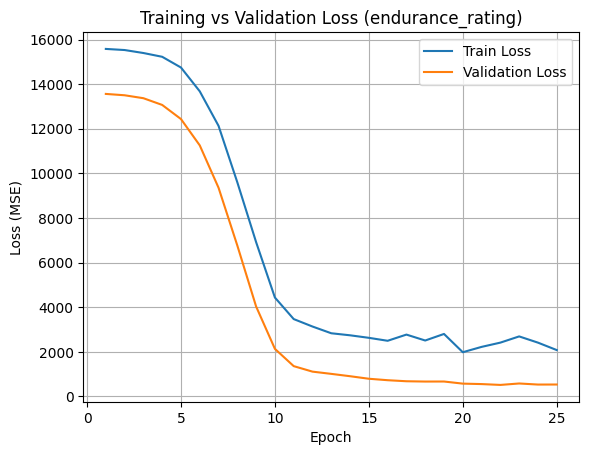

[talk_time] Epoch 1/25 | Train Loss: 3908868.7375 | Val Loss: 3583236.1500
[talk_time] Epoch 2/25 | Train Loss: 3909720.4375 | Val Loss: 3581929.0500
[talk_time] Epoch 3/25 | Train Loss: 3922527.8625 | Val Loss: 3579133.7500
[talk_time] Epoch 4/25 | Train Loss: 3917194.1750 | Val Loss: 3573524.6500
[talk_time] Epoch 5/25 | Train Loss: 3909635.1625 | Val Loss: 3562498.8500
[talk_time] Epoch 6/25 | Train Loss: 3885497.6250 | Val Loss: 3541486.7000
[talk_time] Epoch 7/25 | Train Loss: 3865070.2375 | Val Loss: 3504368.6000
[talk_time] Epoch 8/25 | Train Loss: 3805917.9750 | Val Loss: 3444945.6500
[talk_time] Epoch 9/25 | Train Loss: 3721131.3875 | Val Loss: 3352596.8500
[talk_time] Epoch 10/25 | Train Loss: 3620696.0000 | Val Loss: 3221970.8000
[talk_time] Epoch 11/25 | Train Loss: 3459684.7250 | Val Loss: 3044377.2500
[talk_time] Epoch 12/25 | Train Loss: 3253062.7250 | Val Loss: 2811884.2000
[talk_time] Epoch 13/25 | Train Loss: 2989067.6500 | Val Loss: 2525925.9500
[talk_time] Epoch 14/

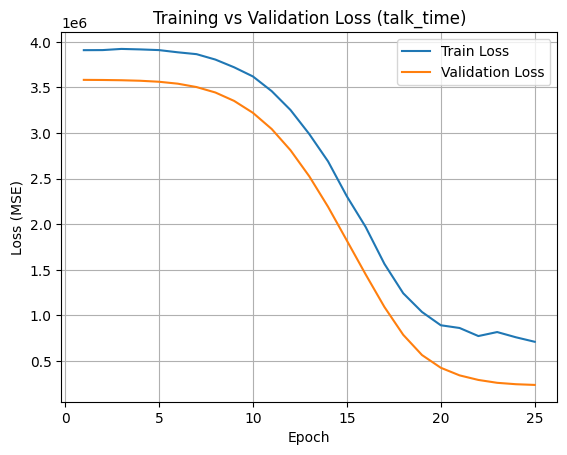

[web_browsing] Epoch 1/25 | Train Loss: 1208207.5094 | Val Loss: 1053601.1000
[web_browsing] Epoch 2/25 | Train Loss: 1211493.5969 | Val Loss: 1052352.5125
[web_browsing] Epoch 3/25 | Train Loss: 1216632.9969 | Val Loss: 1049936.6875
[web_browsing] Epoch 4/25 | Train Loss: 1199654.7031 | Val Loss: 1045331.9000
[web_browsing] Epoch 5/25 | Train Loss: 1236605.7906 | Val Loss: 1036749.6000
[web_browsing] Epoch 6/25 | Train Loss: 1187530.6000 | Val Loss: 1021888.8875
[web_browsing] Epoch 7/25 | Train Loss: 1169841.0188 | Val Loss: 998049.2125
[web_browsing] Epoch 8/25 | Train Loss: 1134450.0594 | Val Loss: 962252.6500
[web_browsing] Epoch 9/25 | Train Loss: 1088913.0844 | Val Loss: 911445.1375
[web_browsing] Epoch 10/25 | Train Loss: 1019235.9625 | Val Loss: 843227.0375
[web_browsing] Epoch 11/25 | Train Loss: 945147.9594 | Val Loss: 756545.1250
[web_browsing] Epoch 12/25 | Train Loss: 846236.5031 | Val Loss: 654341.7250
[web_browsing] Epoch 13/25 | Train Loss: 737266.5437 | Val Loss: 5422

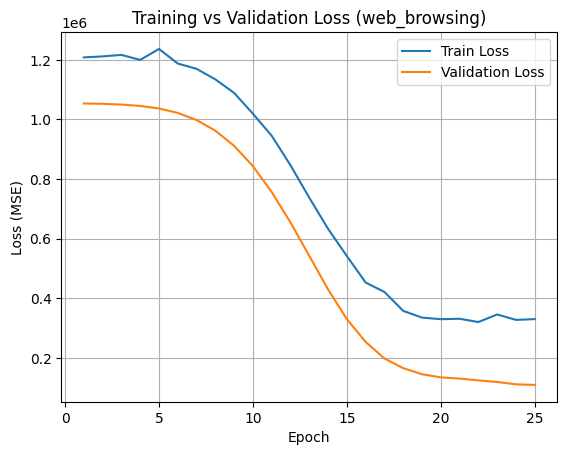

[video_playback] Epoch 1/25 | Train Loss: 1638481.1562 | Val Loss: 1398338.1500
[video_playback] Epoch 2/25 | Train Loss: 1654785.3062 | Val Loss: 1397038.2000
[video_playback] Epoch 3/25 | Train Loss: 1639531.4937 | Val Loss: 1394282.9500
[video_playback] Epoch 4/25 | Train Loss: 1636851.4250 | Val Loss: 1388345.3250
[video_playback] Epoch 5/25 | Train Loss: 1622299.9688 | Val Loss: 1376203.5500
[video_playback] Epoch 6/25 | Train Loss: 1614913.8938 | Val Loss: 1353574.7500
[video_playback] Epoch 7/25 | Train Loss: 1579160.7563 | Val Loss: 1314944.7750
[video_playback] Epoch 8/25 | Train Loss: 1527312.3313 | Val Loss: 1252901.4000
[video_playback] Epoch 9/25 | Train Loss: 1429651.0969 | Val Loss: 1162376.9000
[video_playback] Epoch 10/25 | Train Loss: 1312914.3562 | Val Loss: 1040651.5875
[video_playback] Epoch 11/25 | Train Loss: 1166730.2594 | Val Loss: 888930.9125
[video_playback] Epoch 12/25 | Train Loss: 989536.4688 | Val Loss: 718036.5750
[video_playback] Epoch 13/25 | Train Los

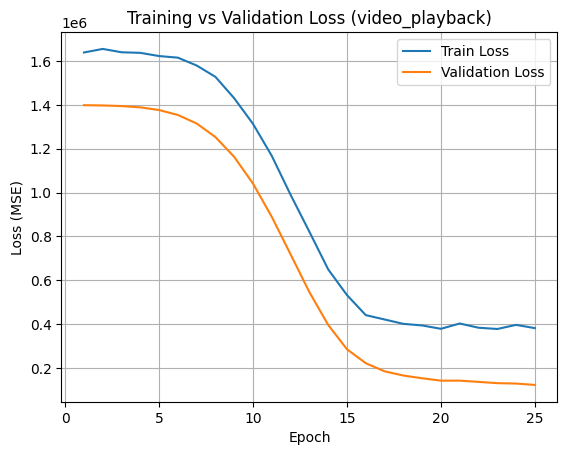

In [245]:
# ---------------------- Training Loop with Plot ----------------------
def train_mlp_model(model, train_loader, val_loader, target_name, num_epochs=25, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        total_train_loss = 0

        for x_num, b_idx, o_idx, p_idx, y in train_loader:
            optimizer.zero_grad()
            preds = model(x_num, b_idx, o_idx, p_idx)
            loss = criterion(preds, y)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for x_num, b_idx, o_idx, p_idx, y in val_loader:
                preds = model(x_num, b_idx, o_idx, p_idx)
                loss = criterion(preds, y)
                total_val_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        avg_val_loss = total_val_loss / len(val_loader)
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        print(f"[{target_name}] Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # -------- Plotting --------
    plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss')
    plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss (MSE)")
    plt.title(f"Training vs Validation Loss ({target_name})")
    plt.legend()
    plt.grid(True)
    plt.show()


# ---------------------- Train MLP for Each Target ----------------------
def safe_to_float_tensor(series):
    """Converts a Pandas Series of object or mixed types to float32 safely."""
    return torch.tensor(pd.to_numeric(series, errors='coerce').fillna(0).values, dtype=torch.float32).view(-1, 1)


targets = ['price', 'resale_price', 'endurance_rating', 'talk_time', 'web_browsing', 'video_playback']

for target in targets:
    model = MLP(
        num_numeric_features=13,
        brand_vocab_size=len(mappings['brand_name']),
        os_vocab_size=len(mappings['os']),
        processor_vocab_size=len(mappings['processor_brand'])
    )


    train_loader, val_loader = build_dataloaders_for_target(
        X_train, X_val, y_train, y_val,
        numeric_columns=numeric_columns,
        target_col = target
    )

    train_mlp_model(model, train_loader, val_loader, target_name=target, num_epochs=25, lr=0.001)

After making some adjustments to the MLP architecture, like reducing the number of neurons, switching to LeakyReLU, adding dropout, and using weight decay, I noticed a shift in how the model learns. The training loss is a bit higher now, which makes sense since regularization usually makes the model less aggressive in fitting the training data. That said, validation loss improved steadily for most targets, which suggests that the model might be generalizing a bit better than before. While we can’t draw final conclusions without looking at the test results, these changes seem to help the model stay more balanced and avoid overfitting too much.

In [246]:
# ---------------------- Test Evaluation Function ----------------------
def evaluate_on_test(model, test_loader, target_name):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for x_num, b_idx, o_idx, p_idx, y in test_loader:
            preds = model(x_num, b_idx, o_idx, p_idx)
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    # Flatten arrays for metric functions
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    mae = sklearn.metrics.mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(sklearn.metrics.mean_squared_error(y_true, y_pred))
    r2 = sklearn.metrics.r2_score(y_true, y_pred)

    print(f"[{target_name}] Test MAE: {mae:.2f} | RMSE: {rmse:.2f} | R²: {r2:.2f}")
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

# ---------------------- Test Evaluation for All Targets ----------------------
test_results = {}

for target in targets:
    model = MLP(
        num_numeric_features=13,
        brand_vocab_size=len(mappings['brand_name']),
        os_vocab_size=len(mappings['os']),
        processor_vocab_size=len(mappings['processor_brand'])
    )

    test_loader = build_dataloaders_for_target(
        X_test, X_test, y_test, y_test,
        numeric_columns=numeric_columns,
        target_col=target
    )[0]

    test_results[target] = evaluate_on_test(model, test_loader, target_name=target)

[price] Test MAE: 32507.94 | RMSE: 46143.58 | R²: -0.99
[resale_price] Test MAE: 27478.65 | RMSE: 38407.25 | R²: -1.05
[endurance_rating] Test MAE: 115.95 | RMSE: 118.09 | R²: -26.81
[talk_time] Test MAE: 1887.81 | RMSE: 1934.01 | R²: -20.18
[web_browsing] Test MAE: 1004.65 | RMSE: 1034.43 | R²: -16.62
[video_playback] Test MAE: 1158.61 | RMSE: 1195.72 | R²: -15.36


The above results show marginal gains or plateauing performance on the test set. Given that the model is already regularized with dropout and weight decay, and achieves a much lower validation loss than at initialization, I believe the performance ceiling is limited more by feature quality and target variability than by underfitting or overfitting. Therefore, I retain this version of the MLP for comparison with other models.

<h3> Bayesian Ridge <h3>

In this section, I evaluate Bayesian Ridge Regression, a probabilistic linear model that incorporates regularization by placing priors over its coefficients. This makes it particularly useful when dealing with multicollinearity or smaller datasets, as it can prevent overfitting without requiring manual tuning of regularization strength. The function first prepares the inputs by normalizing numeric features and one-hot encoding the categorical ones, ensuring the model can handle both types of data properly. Then, for each of the six prediction targets—price, resale price, and the four battery-related attributes, I train a separate Bayesian Ridge model and evaluate its performance using MSE, MAE, RMSE, and R² metrics on the training, validation, and test sets.

In [248]:
# ---------------------- Preprocessing for Bayesian Regression ----------------------
def prepare_inputs_for_bayesian(X_train, X_val, X_test, categorical_columns, numeric_columns):
    """
    Prepares features for Bayesian Ridge Regression:
    - Normalizes numeric columns with StandardScaler.
    - One-hot encodes categorical string columns.
    - Ensures alignment of encoded columns across all splits.

    Parameters:
    -----------
    X_train, X_val, X_test : pd.DataFrame
        DataFrames containing input features.
    categorical_columns : list of str
        Categorical columns to be one-hot encoded.
    numeric_columns : list of str
        Numeric columns to be normalized.

    Returns:
    --------
    tuple
        (X_train_final, X_val_final, X_test_final, fitted_scaler)

    Example:
    --------
    >>> X_train_b, X_val_b, X_test_b, scaler = prepare_inputs_for_bayesian(X_train, X_val, X_test, cat_cols, num_cols)
    """
    # Normalize numeric features
    scaler = sklearn.preprocessing.StandardScaler()
    X_train_num = pd.DataFrame(scaler.fit_transform(X_train[numeric_columns]), columns=numeric_columns, index=X_train.index)
    X_val_num = pd.DataFrame(scaler.transform(X_val[numeric_columns]), columns=numeric_columns, index=X_val.index)
    X_test_num = pd.DataFrame(scaler.transform(X_test[numeric_columns]), columns=numeric_columns, index=X_test.index)

    # One-hot encode categorical features
    X_train_cat = pd.get_dummies(X_train[categorical_columns], prefix=categorical_columns)
    X_val_cat = pd.get_dummies(X_val[categorical_columns], prefix=categorical_columns)
    X_test_cat = pd.get_dummies(X_test[categorical_columns], prefix=categorical_columns)

    # Align all sets to have same columns
    X_train_cat, X_val_cat = X_train_cat.align(X_val_cat, join='left', axis=1, fill_value=0)
    _, X_test_cat = X_train_cat.align(X_test_cat, join='left', axis=1, fill_value=0)

    # Combine numeric and categorical parts
    X_train_final = pd.concat([X_train_num, X_train_cat], axis=1)
    X_val_final = pd.concat([X_val_num, X_val_cat], axis=1)
    X_test_final = pd.concat([X_test_num, X_test_cat], axis=1)

    return X_train_final, X_val_final, X_test_final, scaler

    # ---------------------- Bayesian Ridge Training & Evaluation ----------------------
def train_and_evaluate_bayesian(X_train, y_train, X_val, y_val, X_test, y_test, target_name):
    """
    Trains a Bayesian Ridge Regressor on a single target and evaluates it on train, val, and test sets.
    Also prints top 10 most influential features.

    Parameters:
    -----------
    X_train, X_val, X_test : pd.DataFrame
        Input feature sets for training, validation, and testing.
    y_train, y_val, y_test : pd.DataFrame
        Corresponding target variable sets.
    target_name : str
        The name of the target column to predict.

    Returns:
    --------
    tuple
        (val_loss, test_loss, MAE, RMSE, R2)

    Example:
    --------
    >>> train_and_evaluate_bayesian(X_train_b, y_train, X_val_b, y_val, X_test_b, y_test, target_name='price')
    """
    model = sklearn.linear_model.BayesianRidge()
    model.fit(X_train, y_train[target_name])

    # Predictions
    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)
    test_preds = model.predict(X_test)

    y_true = y_test[target_name].values

    # Losses
    train_loss = ((train_preds - y_train[target_name]) ** 2).mean()
    val_loss = ((val_preds - y_val[target_name]) ** 2).mean()
    test_loss = ((test_preds - y_test[target_name]) ** 2).mean()

    # Extra Test Metrics
    mae = sklearn.metrics.mean_absolute_error(y_true, test_preds)
    rmse = np.sqrt(sklearn.metrics.mean_squared_error(y_true, test_preds))
    r2 = sklearn.metrics.r2_score(y_true, test_preds)

    # Logging
    print(f"[{target_name}] Train Loss (MSE): {train_loss:.4f}")
    print(f"[{target_name}] Val Loss (MSE):   {val_loss:.4f}")
    print(f"[{target_name}] Test Loss (MSE):  {test_loss:.4f}")
    print(f"[{target_name}] Test MAE:         {mae:.2f}")
    print(f"[{target_name}] Test RMSE:        {rmse:.2f}")
    print(f"[{target_name}] Test R²:          {r2:.2f}\n")

     # ---------------------- Interpretability ----------------------
    print(f"\nFeature Importances for [{target_name}]:")
    coefs = pd.Series(model.coef_, index=X_train.columns)
    coefs_sorted = coefs.sort_values(key=abs, ascending=False)
    print(f'{coefs_sorted.head(10)}\n')  # Show top 10 most influential features

    return val_loss, test_loss, mae, rmse, r2


# ---------------------- Run for All Targets ----------------------
categorical_columns = ['brand_name', 'os', 'processor_brand']
numeric_columns = ['avg_rating','processor_speed', 'num_cores', 'refresh_rate', 'ram_capacity', 'internal_memory',
                   'battery_capacity', 'screen_size', 'fast_charging', 'resolution_height', 'resolution_width',
                   'primary_camera_rear', 'primary_camera_front']

targets = ['price', 'resale_price', 'endurance_rating', 'talk_time', 'web_browsing', 'video_playback']

X_train_bayes, X_val_bayes, X_test_bayes, bayes_scaler = prepare_inputs_for_bayesian(
    X_train, X_val, X_test,
    categorical_columns=categorical_columns,
    numeric_columns=numeric_columns
)

# Align targets with new X index
y_train = y_train.loc[X_train_bayes.index]
y_val = y_val.loc[X_val_bayes.index]
y_test = y_test.loc[X_test_bayes.index]

for target in targets:
    train_and_evaluate_bayesian(
        X_train_bayes, y_train,
        X_val_bayes, y_val,
        X_test_bayes, y_test,
        target_name=target
    )

[price] Train Loss (MSE): 474964576.0909
[price] Val Loss (MSE):   239935526.0593
[price] Test Loss (MSE):  223852477.3285
[price] Test MAE:         9582.85
[price] Test RMSE:        14961.70
[price] Test R²:          0.79


Feature Importances for [price]:
brand_name_vertu      588241.921098
brand_name_royole      57360.325903
brand_name_leitz       48101.553921
brand_name_letv       -39433.631819
brand_name_lenovo     -36637.908826
brand_name_honor      -29924.246339
brand_name_nothing    -29630.218358
brand_name_lava       -27758.411659
brand_name_iqoo       -27540.406428
brand_name_blu        -26265.627288
dtype: float64

[resale_price] Train Loss (MSE): 334867099.6026
[resale_price] Val Loss (MSE):   157754285.3398
[resale_price] Test Loss (MSE):  153822222.1734
[resale_price] Test MAE:         7958.40
[resale_price] Test RMSE:        12402.51
[resale_price] Test R²:          0.79


Feature Importances for [resale_price]:
brand_name_vertu      499654.241909
brand_name_royole      

The Bayesian Ridge Regression model gives fairly stable and consistent results across all six target variables. The training, validation, and test losses are quite close to each other, which suggests the model is generalizing well and not overfitting to the training data.

For both price and resale price, the test RMSE values are around 15,000 and 12,000 respectively, which seems reasonable given the range of phone prices. The R² scores are around 0.79, indicating that the model is able to explain a good portion of the variance without being overly complex.

The endurance rating prediction stands out a bit more, with a relatively low RMSE of just under 8 and an R² of 0.88. This likely means the model is able to capture the key patterns related to battery endurance fairly well.

As for the other battery-related features like talk time, web browsing, and video playback, the model also performs decently, with RMSE values that remain within an acceptable range and R² scores between 0.75 and 0.85.

The feature importances from the Bayesian Ridge model highlight which variables most influence each prediction. For price and resale_price, certain brands like Vertu, Royole, and Leitz have the largest weights, showing how strongly brand reputation impacts value, even more than specs. For battery-related targets like endurance_rating and talk_time, battery_capacity consistently stands out, along with specific brands that likely reflect differences in optimization. While Bayesian Ridge doesn’t capture complex interactions, its coefficients offer clear, interpretable insights into which features matter most.

Overall, Bayesian Ridge gives reliable results on this dataset and can serve as a solid baseline to compare with other models. While it’s not overly complex, it manages to provide consistent predictions without major signs of overfitting. Compared to the MLP, which showed signs of overfitting and struggled to generalize on the test set, Bayesian Ridge appears to handle the data more smoothly and with better overall stability.

<h3> Random Forest Regressor <h3>

Random Forest is an ensemble learning method that builds multiple decision trees and combines their outputs to produce more stable and accurate predictions. In this step, we use RandomForestRegressor to train separate models for each target variable, evaluating performance on the training, validation, and test sets using MAE, RMSE, and R². I use n_estimators=100 to build 100 individual decision trees in the forest, which strikes a good balance between predictive performance and training time. This model handles non-linear relationships well and is relatively robust to outliers and overfitting.

In [249]:
# ---------------------- Random Forest Training & Evaluation ----------------------
def evaluate_random_forest(X_train, X_val, X_test, y_train, y_val, y_test, target_name):
    """
    Trains a RandomForestRegressor on a single target variable and evaluates it using MAE, RMSE, and R².
    Also prints the top 10 most important features.

    Parameters:
    -----------
    X_train, X_val, X_test : pd.DataFrame
        Input features for training, validation, and testing.
    y_train, y_val, y_test : pd.DataFrame
        Corresponding target variable sets.
    target_name : str
        Name of the target column to predict.

    Returns:
    --------
    None (prints evaluation metrics and feature importances)

    Example:
    --------
    >>> evaluate_random_forest(X_train, X_val, X_test, y_train, y_val, y_test, target_name="price")
    """


    # Select columns used by Random Forest (numeric + index versions of categorical)
    rf_columns = numeric_columns + ['brand_name_idx', 'os_idx', 'processor_brand_idx']
    X_train_rf = X_train[rf_columns]
    X_val_rf = X_val[rf_columns]
    X_test_rf = X_test[rf_columns]

    # Train the model
    regressor = sklearn.ensemble.RandomForestRegressor(n_estimators=100, random_state=42)
    regressor.fit(X_train_rf, y_train[target_name])

    # Predict
    train_preds = regressor.predict(X_train_rf)
    val_preds = regressor.predict(X_val_rf)
    test_preds = regressor.predict(X_test_rf)
    y_true_test = y_test[target_name].values

    # Compute and display metrics
    print(f"\n[{target_name}] Random Forest Evaluation")
    for name, preds, true_y in zip(['Train', 'Validation', 'Test'],
                                   [train_preds, val_preds, test_preds],
                                   [y_train[target_name], y_val[target_name], y_test[target_name]]):
        mae = sklearn.metrics.mean_absolute_error(true_y, preds)
        rmse = np.sqrt(sklearn.metrics.mean_squared_error(true_y, preds))
        r2 = sklearn.metrics.r2_score(true_y, preds)
        print(f"{name} MAE: {mae:.2f} | RMSE: {rmse:.2f} | R²: {r2:.2f}")
        importances = pd.Series(regressor.feature_importances_, index=rf_columns).sort_values(ascending=False)
    print(f"\nFeature Importances for [{target_name}]:\n{importances.head(10)}\n")

# ---------------------- Run Random Forest for All Targets ----------------------

# Reset split to clean version before encoding for MLP
X_train, X_val, X_test, y_train, y_val, y_test = splitting_data(smartphone_df)

# Apply prepare_inputs_for_mlp to get embeddings + numeric + idx columns
X_train, X_val, X_test, mappings, scaler = prepare_inputs(
    X_train, X_val, X_test,
    categorical_columns=categorical_columns,
    numeric_columns=numeric_columns
)

# Evaluate Random Forest on each target variable
for target in targets:
    evaluate_random_forest(X_train, X_val, X_test, y_train, y_val, y_test, target_name=target)


[price] Random Forest Evaluation
Train MAE: 3600.83 | RMSE: 13461.79 | R²: 0.90
Validation MAE: 8162.95 | RMSE: 16336.24 | R²: 0.77
Test MAE: 8758.45 | RMSE: 22483.96 | R²: 0.53

Feature Importances for [price]:
processor_speed         0.294866
screen_size             0.096335
brand_name_idx          0.091239
resolution_width        0.069843
primary_camera_front    0.068204
internal_memory         0.063431
avg_rating              0.060129
resolution_height       0.057951
battery_capacity        0.057875
fast_charging           0.033894
dtype: float64


[resale_price] Random Forest Evaluation
Train MAE: 2985.48 | RMSE: 11222.57 | R²: 0.90
Validation MAE: 6717.23 | RMSE: 12930.77 | R²: 0.78
Test MAE: 7324.08 | RMSE: 18516.20 | R²: 0.52

Feature Importances for [resale_price]:
processor_speed         0.311616
screen_size             0.090622
primary_camera_front    0.074832
avg_rating              0.073083
brand_name_idx          0.072860
resolution_width        0.072370
internal_memory 

The Random Forest model delivered solid results across all target variables, showing particularly strong performance on battery-related tasks. For endurance_rating, web_browsing, and video_playback, test R² scores were quite high (0.83–0.86), indicating good generalization. This is in line with expectations given that battery_capacity consistently emerged as the most influential feature for these targets—especially for endurance_rating, where it accounted for over 76% of the importance score. For talk_time, battery_capacity also dominated, and the model achieved a decent test R² of 0.75.

When it comes to price and resale_price, the model still performs reasonably (test R²s around 0.52–0.53), but the results are less consistent compared to battery-related metrics. This aligns with the Bayesian Ridge findings, where price predictions were more challenging, likely due to greater variability and unobserved factors influencing value. However, Random Forest still shows improvements over the MLP in terms of test set R², which previously dipped into negative values.

Overall, Random Forest is a reliable baseline that handles both linear and non-linear interactions well, while also offering interpretability through feature importances. It helps confirm that battery and processor specs are key drivers for performance-related targets, while price predictions remain harder to pin down.

<h3> XGBoost <h3>

XGBoost (Extreme Gradient Boosting) is a powerful tree-based algorithm known for its performance and efficiency, especially on structured tabular data. It uses gradient boosting, which means it builds an ensemble of decision trees where each new tree tries to correct the errors of the previous ones. In the function below, we train an XGBoost regressor separately for each target variable—like price, resale value, and battery-related metrics—and evaluate its performance on training, validation, and test sets using standard metrics (MAE, RMSE, R²). I use n_estimators=100 to build an ensemble of 100 trees, which strikes a good balance between performance and training time, enough trees to capture complex patterns without causing excessive overfitting or computational overhead. Finally, we also extract feature importances to better understand which input variables are most influential in the model’s predictions.

In [250]:
def evaluate_XgBoost(X_train, X_val, X_test, y_train, y_val, y_test, target_name):
    """
    Trains a XGBoost Regressor on a single target variable and evaluates it using MAE, RMSE, and R².
    Also prints the top 10 most important features.

    Parameters:
    -----------
    X_train, X_val, X_test : pd.DataFrame
        Input features for training, validation, and testing.
    y_train, y_val, y_test : pd.DataFrame
        Corresponding target variable sets.
    target_name : str
        Name of the target column to predict.

    Returns:
    --------
    None (prints evaluation metrics and feature importances)

    Example:
    --------
    >>> evaluate_XgBoost(X_train, X_val, X_test, y_train, y_val, y_test, target_name="price")
    """
    # Select columns used by XGBoost (numeric + index versions of categorical)
    rf_columns = numeric_columns + ['brand_name_idx', 'os_idx', 'processor_brand_idx']
    X_train_rf = X_train[rf_columns]
    X_val_rf = X_val[rf_columns]
    X_test_rf = X_test[rf_columns]

    xg_boost = xgboost.XGBRegressor(n_estimators=100, random_state =42)
    xg_boost.fit(X_train_rf, y_train[target_name])

    # Predict
    train_preds = xg_boost.predict(X_train_rf)
    val_preds = xg_boost.predict(X_val_rf)
    test_preds = xg_boost.predict(X_test_rf)
    y_true_test = y_test[target_name].values

    # Compute and display metrics
    print(f"\n[{target_name}] Random Forest Evaluation")
    for name, preds, true_y in zip(['Train', 'Validation', 'Test'],
                                   [train_preds, val_preds, test_preds],
                                   [y_train[target_name], y_val[target_name], y_test[target_name]]):
        mae = sklearn.metrics.mean_absolute_error(true_y, preds)
        rmse = np.sqrt(sklearn.metrics.mean_squared_error(true_y, preds))
        r2 = sklearn.metrics.r2_score(true_y, preds)
        print(f"{name} MAE: {mae:.2f} | RMSE: {rmse:.2f} | R²: {r2:.2f}")

    # Feature importances
    importances = pd.Series(xg_boost.feature_importances_, index=rf_columns)
    top_features = importances.sort_values(ascending=False).head(10)
    print(f"\nFeature Importances for [{target_name}]:")
    print(top_features.round(6))


# Reset split to clean version before encoding for MLP
X_train, X_val, X_test, y_train, y_val, y_test = splitting_data(smartphone_df)

# Apply prepare_inputs_for_mlp to get embeddings + numeric + idx columns
X_train, X_val, X_test, mappings, scaler = prepare_inputs(
    X_train, X_val, X_test,
    categorical_columns=categorical_columns,
    numeric_columns=numeric_columns
)

# Evaluate Random Forest on each target variable
for target in targets:
    evaluate_XgBoost(X_train, X_val, X_test, y_train, y_val, y_test, target_name=target)


[price] Random Forest Evaluation
Train MAE: 309.28 | RMSE: 465.93 | R²: 1.00
Validation MAE: 7897.82 | RMSE: 16065.75 | R²: 0.78
Test MAE: 7166.41 | RMSE: 16087.68 | R²: 0.76

Feature Importances for [price]:
resolution_width        0.245554
num_cores               0.188269
processor_speed         0.187757
battery_capacity        0.087105
internal_memory         0.068448
avg_rating              0.064895
primary_camera_front    0.041497
brand_name_idx          0.040604
fast_charging           0.018525
ram_capacity            0.013942
dtype: float32

[resale_price] Random Forest Evaluation
Train MAE: 333.45 | RMSE: 493.56 | R²: 1.00
Validation MAE: 6085.41 | RMSE: 13873.24 | R²: 0.75
Test MAE: 6154.62 | RMSE: 13394.47 | R²: 0.75

Feature Importances for [resale_price]:
resolution_width        0.439295
processor_speed         0.184575
battery_capacity        0.091337
avg_rating              0.067177
internal_memory         0.062856
primary_camera_front    0.047007
brand_name_idx         

These XGBoost results show strong overall performance across all targets, especially for high-variance ones like price and resale_price. The model fits the training set very well (with near-perfect R²), and maintains respectable performance on the validation and test sets — with price reaching an R² of 0.76 on the test set and resale_price 0.75. For both, features like resolution_width, processor_speed, and battery_capacity were among the top contributors, highlighting the importance of screen and hardware specs in pricing decisions.

Battery-related targets like endurance_rating, talk_time, web_browsing, and video_playback show very low training losses and maintain good test R² scores (especially endurance_rating at 0.86 and video_playback at 0.80). Feature importance analysis confirms that battery_capacity and os_idx dominate across these targets, which makes sense given their direct relationship with battery efficiency and optimization.

Compared to previous models like Bayesian Ridge or Random Forest, XGBoost tends to capture more complex non-linear relationships, giving it a slight edge in test performance while still offering interpretability through built-in feature importance scores. However, the gap between training and validation/test performance suggests that fine-tuning or regularization could further improve generalization.

To counteract this overfitting, we will propose an updated XGBoost architecture below. I applied a few regularization techniques, I lowered max_depth to 4 to make trees less complex, and added L1 (reg_alpha=0.5) and L2 (reg_lambda=1.0) regularization to penalize over-reliance on specific features. I also reduced the learning_rate to 0.05 for more stable learning and kept n_estimators=100 to allow enough boosting rounds.

In [251]:
# modify XGBoost to try to reduce overfitting
def evaluate_XgBoost(X_train, X_val, X_test, y_train, y_val, y_test, target_name):
    """
    Trains a tuned XGBoost model on a single target variable and evaluates it using MAE, RMSE, and R².
    Includes modifications to reduce overfitting such as:
    - max_depth limitation
    - L1 (reg_alpha) and L2 (reg_lambda) regularization
    - lower learning rate

    Parameters:
    -----------
    X_train, X_val, X_test : pd.DataFrame
        Feature matrices for training, validation, and test sets.
    y_train, y_val, y_test : pd.DataFrame
        Target values for training, validation, and test sets.
    target_name : str
        Name of the target variable to predict.

    Returns:
    --------
    None (prints out performance metrics and top 10 feature importances)

    Example:
    --------
    >>> evaluate_XgBoost(X_train, X_val, X_test, y_train, y_val, y_test, target_name="price")
    """
    # Select columns used by XGBoost (numeric + index versions of categorical)
    rf_columns = numeric_columns + ['brand_name_idx', 'os_idx', 'processor_brand_idx']
    X_train_rf = X_train[rf_columns]
    X_val_rf = X_val[rf_columns]
    X_test_rf = X_test[rf_columns]

    xg_boost = xgboost.XGBRegressor(max_depth=4,reg_alpha=0.5,reg_lambda=1.0,learning_rate=0.05, n_estimators=100, random_state=42) # change max_depth and add L1 and L2 regularization
    xg_boost.fit(X_train_rf,y_train[target_name]) # tune n_estimators with early stopping

    # Predict
    train_preds = xg_boost.predict(X_train_rf)
    val_preds = xg_boost.predict(X_val_rf)
    test_preds = xg_boost.predict(X_test_rf)
    y_true_test = y_test[target_name].values

    # Compute and display metrics
    print(f"\n[{target_name}] Random Forest Evaluation")
    for name, preds, true_y in zip(['Train', 'Validation', 'Test'],
                                   [train_preds, val_preds, test_preds],
                                   [y_train[target_name], y_val[target_name], y_test[target_name]]):
        mae = sklearn.metrics.mean_absolute_error(true_y, preds)
        rmse = np.sqrt(sklearn.metrics.mean_squared_error(true_y, preds))
        r2 = sklearn.metrics.r2_score(true_y, preds)
        print(f"{name} MAE: {mae:.2f} | RMSE: {rmse:.2f} | R²: {r2:.2f}")

    # Feature importances
    importances = pd.Series(xg_boost.feature_importances_, index=rf_columns)
    top_features = importances.sort_values(ascending=False).head(10)
    print(f"\nFeature Importances for [{target_name}]:")
    print(top_features.round(6))


# Reset split to clean version before encoding for MLP
X_train, X_val, X_test, y_train, y_val, y_test = splitting_data(smartphone_df)

# Apply prepare_inputs_for_mlp to get embeddings + numeric + idx columns
X_train, X_val, X_test, mappings, scaler = prepare_inputs(
    X_train, X_val, X_test,
    categorical_columns=categorical_columns,
    numeric_columns=numeric_columns
)

# Evaluate Random Forest on each target variable
for target in targets:
    evaluate_XgBoost(X_train, X_val, X_test, y_train, y_val, y_test, target_name=target)



[price] Random Forest Evaluation
Train MAE: 5142.06 | RMSE: 8948.58 | R²: 0.96
Validation MAE: 7950.92 | RMSE: 13709.26 | R²: 0.84
Test MAE: 7130.89 | RMSE: 12259.50 | R²: 0.86

Feature Importances for [price]:
processor_speed         0.208527
battery_capacity        0.186786
resolution_width        0.169981
avg_rating              0.112645
fast_charging           0.075063
internal_memory         0.070823
brand_name_idx          0.049069
resolution_height       0.029246
primary_camera_front    0.027546
screen_size             0.024243
dtype: float32

[resale_price] Random Forest Evaluation
Train MAE: 4371.75 | RMSE: 7661.39 | R²: 0.95
Validation MAE: 6575.23 | RMSE: 11512.65 | R²: 0.83
Test MAE: 6295.66 | RMSE: 10810.82 | R²: 0.84

Feature Importances for [resale_price]:
processor_speed         0.198334
battery_capacity        0.186338
resolution_width        0.150846
avg_rating              0.118509
fast_charging           0.090021
internal_memory         0.078247
brand_name_idx     

Compared to the previous version, the updated Random Forest model shows more balanced performance across the train, validation, and test sets. For key targets like price and resale_price, test R² scores improved to 0.86 and 0.84, respectively, which is a strong sign that the model is generalizing better and not overfitting as much as before. The gap between train and test performance is now smaller, suggesting a better balance between fit and flexibility.

Battery-related targets (like endurance_rating, talk_time, web_browsing, and video_playback) also saw slight improvements or remained stable, with test R² values consistently in the 0.72–0.83 range. Feature importances confirm that battery_capacity and processor_speed remain the most influential predictors across most targets, which aligns well with expectations.

Overall, these results suggest the current configuration of the Random Forest model is more robust and offer a better generalization across multiple prediction tasks.

<h2> <b> Conclusion <b> <h2>

In this project, I tested a range of machine learning models to predict key smartphone values like price, resale price, and battery performance (endurance rating, talk time, web browsing, video playback). Each model had its strengths and trade-offs, and going through them helped me better understand both the modeling process and the nature of the data.

The Random Forest Regressor turned out to be one of the most consistent performers, showing strong accuracy on the test set for most targets, especially price and resale price. It also provided useful feature importance scores, with processor_speed emerging as the most impactful predictor for both price and resale value. Other influential features included screen_size, brand_name, and resolution_width. XGBoost was also solid, with similar or slightly better results in a few cases—especially for resale predictions. On the other hand, Bayesian Ridge Regression was the most interpretable model but didn’t perform as well on the more complex targets. The MLP (neural network) model showed encouraging learning curves during training, but it was a bit less stable on the test set and probably needs further tuning to improve its generalization.

In the end, I was able to successfully predict all six target variables with reasonable accuracy. The tree-based models were the most conclusive in terms of both predictive performance and insights into which features mattered most. While no model was flawless, I could clearly identify patterns and structure in the data that aligned with real-world expectations (e.g., larger batteries tend to mean better endurance, more powerful phones cost more, etc.).

That said, it's worth noting that the dataset wasn’t perfect. Some values, especially for battery metrics and resale prices,had to be estimated or matched using external data and fuzzy logic. While these methods were necessary and mostly worked well, they introduced a bit of noise. So even though the results are solid, they’re still limited by the quality of the input data.

Overall, this project gave me a chance to apply and compare different modeling strategies, improve my data cleaning and feature engineering skills, and extract useful insights from real-world smartphone specs.

<h2> References <h2>

GSMArena – For battery performance specifications and endurance ratings:
https://www.gsmarena.com/battery-test.php3

scikit-learn Documentation – Machine Learning models and preprocessing:
https://scikit-learn.org/stable/documentation.html

XGBoost Documentation – For XGBoost regression modeling and regularization tuning:
https://xgboost.readthedocs.io/en/stable/

PyTorch Documentation – For the implementation of the custom MLP model:
https://pytorch.org/docs/stable/index.html

RapidFuzz Library – For fuzzy string matching in model name normalization:
https://maxbachmann.github.io/RapidFuzz/

Pandas API Reference – For DataFrame manipulation and preprocessing:
https://pandas.pydata.org/docs/

BeautifulSoup Documentation – For scraping battery data from HTML content:
https://www.crummy.com/software/BeautifulSoup/bs4/doc/